# Lab Exam 3, AI for Communication and Marketing

*Beatrice Camera, 535313*

Customer Lifetime Value is an analytical tool that estimates the total net profit or revenue a customer will generate throughout their entire relationship with a business. Therefore, it is the metric that connects marketing spend to long-term business outcomes. This analysis asks a fundamental question: *how much is each customer worth over their lifetime* and how should that estimate shape budget allocation, retention investment, and win-back prioritisation?

**Business context.** As Lead Data Scientist for Olist, Brazil's largest e-commerce marketplace, the task is to build a predictive CLTV framework from a multi-table transactional dataset. Olist data arrives as a relational schema: five tables covering orders, customers, items, payments, and reviews must be joined, validated, and aggregated into a customer-level format before any modelling can begin. 

Two modelling approaches are developed in parallel. A probabilistic Buy Till You Die (BTYD) using two models Beta Geometric Negative Binomial Distribution (BG/NBD) and  Gamma-Gamma, that captures the stochastic nature of customer purchasing behaviour, estimating both the expected number of future transactions and the probability that a customer is still active. A machine learning approach (XGBoost Regressor) uses engineered features from the calibration period to predict holdout revenue directly. The comparison between the two is not treated as competition; indeed each model is better suited to a specific business question, and the choice between them depends on whether the goal is macro financial planning or micro-level customer targeting.

The analysis is organised as follows:

- **Section 1, Data Engineering & Audit**: relational join pipeline, cleaning, and anomaly detection
- **Section 2, Exploratory Data Analysis**: purchase behaviour distributions, retention insights, and RFM feature engineering
- **Section 3, Modeling & Evaluation**: BTYD probabilistic model, ML regressor, and comparative evaluation
- **Section 4, Communication Strategy**: CLTV-based budget allocation and win-back campaign design
- **Section 5, from Model to Production**: batch scoring pipeline, live CRM integration, and retraining strategy
- **Section 6, Conclusion**

In [1]:
import subprocess, sys
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install',
    'lifetimes', 'xgboost', '--quiet'
])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import io, requests
from datetime import timedelta

from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data, calibration_and_holdout_data
from lifetimes.plotting import plot_calibration_purchases_vs_holdout_purchases

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_colwidth', None)

GREEN_DARK   = '#1A3D2B'   
GREEN_MID    = '#1E6B45'  
GREEN_LIGHT  = '#3A9B6F'  
GREEN_PALE   = '#7EC8A0'   
ACCENT_RED   = '#C0392B'   
ACCENT_GOLD  = '#B8860B'   
ACCENT_NAVY  = '#1B2A4A'   

sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams.update({
    'figure.dpi'         : 110,
    'axes.titlesize'     : 12,
    'axes.labelsize'     : 10,
    'xtick.labelsize'    : 9,
    'ytick.labelsize'    : 9,
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
})

RANDOM_STATE = 42
print('Setup complete.')

Setup complete.


In [2]:
BASE_URL = 'https://raw.githubusercontent.com/BeatriceCamera/AI4CM_projects/main/'

orders    = pd.read_csv(BASE_URL + 'olist_orders_dataset.csv',
                        parse_dates=['order_purchase_timestamp',
                                     'order_delivered_customer_date',
                                     'order_estimated_delivery_date'])
customers = pd.read_csv(BASE_URL + 'olist_customers_dataset.csv')
items     = pd.read_csv(BASE_URL + 'olist_order_items_dataset.csv')
payments  = pd.read_csv(BASE_URL + 'olist_order_payments_dataset.csv')
reviews   = pd.read_csv(BASE_URL + 'olist_order_reviews_dataset.csv',
                        parse_dates=['review_creation_date',
                                     'review_answer_timestamp'])
products  = pd.read_csv(BASE_URL + 'olist_products_dataset.csv')
cat_trans = pd.read_csv(BASE_URL + 'product_category_name_translation.csv')

print('All tables loaded.')
for name, tbl in [('orders', orders), ('customers', customers),
                   ('items', items), ('payments', payments),
                   ('reviews', reviews), ('products', products)]:
    print(f'  {name:12s}: {tbl.shape[0]:>7,} rows × {tbl.shape[1]} columns')

All tables loaded.
  orders      :  99,441 rows × 8 columns
  customers   :  99,441 rows × 5 columns
  items       : 112,650 rows × 7 columns
  payments    : 103,886 rows × 5 columns
  reviews     :  99,224 rows × 7 columns
  products    :  32,951 rows × 9 columns


## 1. Data Audit and Quality

The Olist dataset is a relational schema: customer identity, order history, item-level transactions, payment records, and satisfaction reviews are stored across five separate tables. No single table contains sufficient information for CLTV modelling, a customer's lifetime value requires knowing *who* they are (customers), *when* they ordered (orders), *how much* they paid (payments), and *what* they bought (items). Building a reliable analytical base therefore requires a principled join pipeline before any cleaning or feature engineering can begin.

This distinction is important for data quality. Errors introduced at the join stage (fan-out from one-to-many relationships, loss of customers through inner joins, duplication from multi-item orders) propagate silently through every downstream calculation. A customer whose revenue is double-counted produces a CLTV estimate that is structurally wrong, regardless of how sophisticated the model fitting is.

The pipeline proceeds in three stages:
1. **Schema validation:** understand the cardinality of each relationship before joining
2. **Relational assembly:** construct the transaction-level table with documented row counts at each step
3. **Cleaning and filtering:** remove invalid transactions, handle cancellations, cap outliers, and define the observation window

In [3]:
# Cardinality check, understand relationships before joining
print('--- Cardinality Check ---')

# orders → customers: each order belongs to one customer_id
# but customer_id ≠ customer_unique_id (one person can have multiple customer_ids)
n_customer_ids   = customers['customer_id'].nunique()
n_unique_ids     = customers['customer_unique_id'].nunique()
print(f'customer_id (transactional) : {n_customer_ids:,}')
print(f'customer_unique_id (person) : {n_unique_ids:,}')
print(f'Ratio: {n_customer_ids / n_unique_ids:.3f} — some persons have multiple IDs')

# orders → items: one order can have multiple items (fan-out risk)
items_per_order = items.groupby('order_id')['order_item_id'].max()
print(f'\nMax items per order    : {items_per_order.max()}')
print(f'Median items per order : {items_per_order.median()}')
print(f'Orders with >1 item    : {(items_per_order > 1).sum():,} ({(items_per_order > 1).mean()*100:.1f}%)')

# payments: one order can have multiple payment records (installments)
payments_per_order = payments.groupby('order_id')['payment_sequential'].max()
print(f'\nOrders with >1 payment record: {(payments_per_order > 1).sum():,}')
print('→ Payments must be aggregated to order level before joining')

--- Cardinality Check ---
customer_id (transactional) : 99,441
customer_unique_id (person) : 96,096
Ratio: 1.035 — some persons have multiple IDs

Max items per order    : 21
Median items per order : 1.0
Orders with >1 item    : 9,803 (9.9%)

Orders with >1 payment record: 3,039
→ Payments must be aggregated to order level before joining


Two structural observations shape the join strategy.

First, `customer_id` in the Olist schema is a transaction-level identifier, not a person-level one. A single customer who makes multiple purchases receives a different `customer_id` for each order. For CLTV modelling, which requires tracking a person's purchasing history over time, the correct identifier is `customer_unique_id`. Joining on `customer_id` without this correction would treat repeat purchasers as new customers, systematically understating frequency and overstating the customer base size.

Second, the payments table has a one-to-many relationship with orders: a single order paid in installments generates multiple payment rows. Aggregating payments to order level before joining prevents revenue from being counted multiple times per order.

Together, these checks confirm that customer identity and payment aggregation must be handled before any transactional modelling is performed, otherwise frequency and monetary estimates would be systematically biased.

In [4]:
rows = {}  # track row count at each step for the audit summary

# Step 1: Aggregate payments to order level
# Sum payment_value across all payment records for the same order
payments_agg = (
    payments
    .groupby('order_id', as_index=False)
    .agg(payment_value=('payment_value', 'sum'),
         n_payment_types=('payment_type', 'nunique'))
)
rows['payments_agg'] = len(payments_agg)

# Step 2: Aggregate items to order level
# Sum price and freight; count items; keep product diversity signal
items_agg = (
    items
    .groupby('order_id', as_index=False)
    .agg(n_items=('order_item_id', 'max'),
         items_revenue=('price', 'sum'),
         freight_value=('freight_value', 'sum'),
         n_unique_products=('product_id', 'nunique'))
)
rows['items_agg'] = len(items_agg)

# Step 3: Aggregate reviews to order level (take most recent per order)
reviews_agg = (
    reviews
    .sort_values('review_answer_timestamp')
    .groupby('order_id', as_index=False)
    .agg(review_score=('review_score', 'last'))
)
rows['reviews_agg'] = len(reviews_agg)

# Step 4: Build order-level base (orders + customer unique ID)
base = (
    orders
    .merge(customers[['customer_id', 'customer_unique_id', 'customer_state']],
           on='customer_id', how='left')
)
rows['orders_customers'] = len(base)

# Step 5: Join items, payments, reviews
base = base.merge(items_agg,    on='order_id', how='left')
base = base.merge(payments_agg, on='order_id', how='left')
base = base.merge(reviews_agg,  on='order_id', how='left')
rows['after_joins'] = len(base)

print('Pipeline row counts (no rows should explode):')
for step, n in rows.items():
    print(f'  {step:25s}: {n:>7,}')
print(f'\nBase columns: {list(base.columns)}')

Pipeline row counts (no rows should explode):
  payments_agg             :  99,440
  items_agg                :  98,666
  reviews_agg              :  98,673
  orders_customers         :  99,441
  after_joins              :  99,441

Base columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_state', 'n_items', 'items_revenue', 'freight_value', 'n_unique_products', 'payment_value', 'n_payment_types', 'review_score']


The aggregation pipeline preserves the expected order-level granularity throughout the joins. The final table contains the same number of rows as the original orders dataset (99,441), confirming that no unintended row duplication occurred during the integration of items, payments, reviews, and customer information. This provides a reliable transactional base for the subsequent CLTV analysis.

The equality between the original order count (99,441) and the final assembled table confirms that the aggregation strategy successfully avoided row explosion, one of the most common pitfalls when integrating transactional datasets with one-to-many relationships.

### **1.1 Duplicates**

This section performes a quick check to be sure that no duplicates are present in the data. 

In [5]:
# Duplicate check on the assembled base table
full_dups     = base.duplicated().sum()
order_id_dups = base.duplicated(subset='order_id').sum()

print(f'Full duplicate rows     : {full_dups}')
print(f'Duplicate order_id rows : {order_id_dups}')

if full_dups > 0:
    base = base.drop_duplicates()
    print(f'Duplicates removed. Remaining rows: {len(base):,}')
else:
    print('No duplicates found —> no action required.')

Full duplicate rows     : 0
Duplicate order_id rows : 0
No duplicates found —> no action required.


### **1.2 Missing Value Analysis**

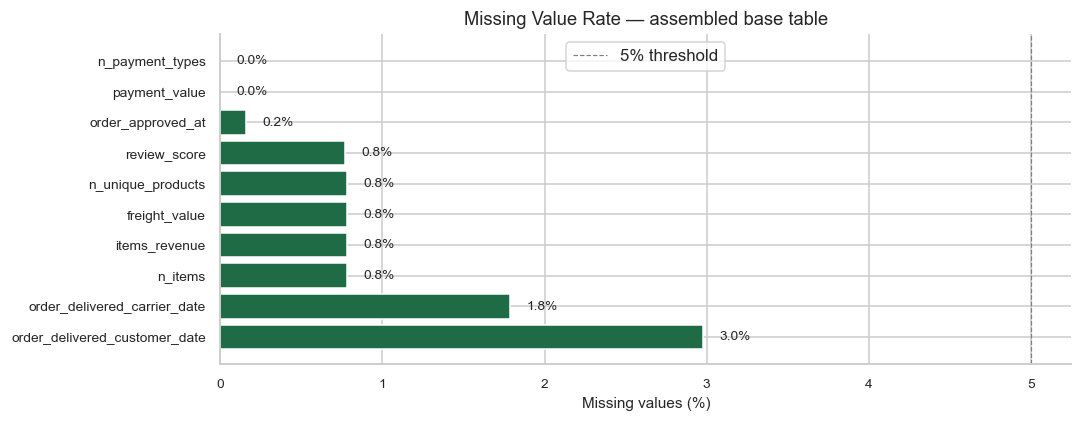

                               Missing Count  Missing %
order_delivered_customer_date           2965       2.98
order_delivered_carrier_date            1783       1.79
n_items                                  775       0.78
items_revenue                            775       0.78
freight_value                            775       0.78
n_unique_products                        775       0.78
review_score                             768       0.77
order_approved_at                        160       0.16
payment_value                              1       0.00
n_payment_types                            1       0.00


In [6]:
# Missing value audit on assembled base table
missing = base.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %'    : (missing / len(base) * 100).round(2)
})

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(missing_report.index, missing_report['Missing %'],
               color=GREEN_MID, edgecolor='white')
ax.axvline(5, color='grey', linestyle='--', linewidth=0.8, label='5% threshold')
for bar, pct in zip(bars, missing_report['Missing %']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Missing values (%)')
ax.set_title('Missing Value Rate — assembled base table', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

print(missing_report)

All missing rates are below 5% and arise from identifiable business processes rather than random data quality issues.

Missing delivery dates (`order_delivered_customer_date`, `order_delivered_carrier_date`) correspond to orders that had not yet completed delivery when the dataset was extracted. Since RFM relies on purchase timestamps, these fields are not used and require no imputation.

The item-level variables (`n_items`, `items_revenue`, `freight_value`, `n_unique_products`) share the same missing pattern (0.78%), indicating orders without associated item records. These cases are rare (<1%) and will be handled during the cleaning phase once the final transactional table is filtered for valid revenue-generating orders.

Missing `review_score` values (0.77%) simply reflect customers who did not submit a review. As review score is used only for exploratory analysis, missing values are retained and handled only when required.

The remaining missing values (`order_approved_at` and a single `payment_value`) are negligible and are naturally resolved by the cleaning pipeline.

### **1.3 Cleaning and Observation Window**

In [7]:
# Order status distribution, understand what needs to be filtered
print('Order status distribution:')
print(base['order_status'].value_counts().to_string())

Order status distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2


The vast majority of transactions correspond to delivered orders, while cancelled, unavailable, processing and invoiced orders represent a small minority of the dataset.

For CLTV modelling, only completed deliveries generate realised customer value. Orders that were cancelled or never fulfilled do not correspond to actual revenue events and therefore cannot contribute to customer lifetime value estimation.

**On cancellations**. the Olist dataset does not contain an explicit returns table. Consequently, cancelled and unavailable statuses represent the primary form of invalid transaction. Including them as zero-value purchases would distort monetary estimates and artificially inflate customer activity. They are therefore removed from the analytical base rather than imputed.

The dataset does not contain an explicit return transaction table. Consequently, cancelled and unavailable orders are treated as the primary form of invalid transaction and removed from the analytical base.

In [8]:
n_before = len(base)

# 1. Keep only delivered orders
# Cancelled, unavailable, and processing orders do not represent completed revenue events and would corrupt the RFM calculation
df = base[base['order_status'] == 'delivered'].copy()
print(f'After keeping delivered only : {len(df):,} (removed {n_before - len(df):,})')

# 2. Remove rows with missing purchase timestamp or customer ID
n = len(df)
df = df.dropna(subset=['order_purchase_timestamp', 'customer_unique_id', 'payment_value'])
print(f'After dropping missing keys  : {len(df):,} (removed {n - len(df):,})')

# 3. Remove transactions with zero or negative payment value
n = len(df)
df = df[df['payment_value'] > 0]
print(f'After removing zero revenue  : {len(df):,} (removed {n - len(df):,})')

# 4. Define observation window
# Olist covers Oct 2016 – Aug 2018, but early months have very low volume (ramp-up period not representative of steady-state behaviour).
# I restrict to Jan 2017 – Jul 2018 to use only the mature operating period.
n = len(df)
df = df[
    (df['order_purchase_timestamp'] >= '2017-01-01') &
    (df['order_purchase_timestamp'] <= '2018-07-31')
].copy()
print(f'After observation window     : {len(df):,} (removed {n - len(df):,})')

# 5. Cap payment_value at 99th percentile (sentinel values)
p99 = df['payment_value'].quantile(0.99)
n_capped = (df['payment_value'] > p99).sum()
df['payment_value'] = df['payment_value'].clip(upper=p99)
print(f'Payment_value capped at P99 R${p99:.2f}: {n_capped} values')

print(f'\nFinal transaction table: {len(df):,} orders | {df["customer_unique_id"].nunique():,} unique customers')
print(f'Date range: {df["order_purchase_timestamp"].min().date()} → {df["order_purchase_timestamp"].max().date()}')

After keeping delivered only : 96,478 (removed 2,963)
After dropping missing keys  : 96,477 (removed 1)
After removing zero revenue  : 96,477 (removed 0)
After observation window     : 89,547 (removed 6,930)
Payment_value capped at P99 R$1052.43: 896 values

Final transaction table: 89,547 orders | 86,655 unique customers
Date range: 2017-01-05 → 2018-07-30


The cleaning process progressively removes transactions that do not represent valid customer purchasing behaviour. Only delivered orders are retained, records with missing key identifiers are excluded, and extreme payment values are capped at the 99th percentile to reduce the influence of unusually large purchases.

The resulting analytical table contains 89,547 valid transactions generated by 86,655 unique customers.

**On the observation window decision**. The Olist dataset spans October 2016 to August 2018, but the first three months represent the platform's ramp-up period, where order volumes are substantially lower than during the steady-state operating phase beginning in January 2017. Including this period would distort RFM distributions, making early customers appear artificially inactive simply because the platform itself had not yet reached normal operating scale. Restricting the observation window to January 2017 onwards ensures that customer behaviour is measured under representative business conditions.

In [9]:
# Cleaning audit summary
cleaning_summary = pd.DataFrame({
    'Metric': [
        'Raw orders (all statuses)',
        'Delivered orders only',
        'After removing missing keys',
        'After removing zero revenue',
        'After observation window (Jan 2017 – Jul 2018)',
        'Payment_value capped at P99',
        'Unique customers (final)',
    ],
    'Value': [
        f'{n_before:,}',
        f'{len(base[base["order_status"]=="delivered"]):,}',
        'See print above',
        'See print above',
        f'{len(df):,} orders',
        f'{n_capped} values capped at R${p99:.2f}',
        f'{df["customer_unique_id"].nunique():,}',
    ],
    'Rationale': [
        'Starting point',
        'Only completed deliveries represent revenue events',
        'CLTV requires date, ID, and value, missing any is unrecoverable',
        'Zero-value orders are failed transactions, not low-spend signals',
        'Ramp-up period (Oct–Dec 2016) is not representative of steady-state behaviour',
        'Extreme outliers distort Gamma-Gamma monetary estimation',
        'Unique persons via customer_unique_id, not transactional customer_id',
    ]
})
cleaning_summary.set_index('Metric')

,Value,Rationale
Metric,,
Raw orders (all statuses),"99,441",Starting point
Delivered orders only,"96,478",Only completed deliveries represent revenue events
After removing missing keys,See print above,"CLTV requires date, ID, and value, missing any is unrecoverable"
After removing zero revenue,See print above,"Zero-value orders are failed transactions, not low-spend signals"
After observation window (Jan 2017 – Jul 2018),"89,547 orders",Ramp-up period (Oct–Dec 2016) is not representative of steady-state behaviour
Payment_value capped at P99,896 values capped at R$1052.43,Extreme outliers distort Gamma-Gamma monetary estimation
Unique customers (final),"86,655","Unique persons via customer_unique_id, not transactional customer_id"


## 2. Exploratory Data Analysis

The cleaning phase produced a reliable transaction table: 18 months of delivered orders from Olist's mature operating period, with revenue validated, anomalies removed, and customer identity resolved at the person level rather than the transaction level. The EDA now shifts the question from *'is this data trustworthy?'* to *'what does this data reveal about how customers purchase over time?'*

Four lines of inquiry structure the analysis:
1. **Purchase behaviour distributions:** how are frequency, recency, and monetary value distributed across the customer base, and what do those distributions imply for modelling assumptions?
2. **Retention and repeat purchase patterns:** what share of customers make more than one purchase, and how does that pattern vary over time?
3. **Geographic value distribution**: Olist operates across all 27 Brazilian states, and purchasing behaviour varies substantially across regions. Understanding where customer value is concentrated provides additional context for resource allocation and future marketing investment.
4. **RFM feature engineering:** transform the transaction table into the customer-level summary format required by the `lifetimes` library

In [10]:
# Customer-level aggregation for EDA
cust_eda = (
    df.groupby('customer_unique_id')
    .agg(
        n_orders        = ('order_id',                'nunique'),
        total_revenue   = ('payment_value',           'sum'),
        avg_order_value = ('payment_value',           'mean'),
        first_order     = ('order_purchase_timestamp', 'min'),
        last_order      = ('order_purchase_timestamp', 'max'),
        avg_review      = ('review_score',            'mean'),
        customer_state  = ('customer_state',          'first'),
    )
    .reset_index()
)

obs_end = df['order_purchase_timestamp'].max()
cust_eda['recency_days'] = (obs_end - cust_eda['last_order']).dt.days
cust_eda['tenure_days']  = (cust_eda['last_order'] - cust_eda['first_order']).dt.days

print(f'Customer-level EDA table: {len(cust_eda):,} customers')
print(f'Repeat purchasers (≥2 orders): {(cust_eda["n_orders"] >= 2).sum():,} '
      f'({(cust_eda["n_orders"] >= 2).mean()*100:.1f}%)')
cust_eda[['n_orders','total_revenue','avg_order_value','recency_days']].describe().T.round(2)

Customer-level EDA table: 86,655 customers
Repeat purchasers (≥2 orders): 2,602 (3.0%)


,count,mean,std,min,25%,50%,75%,max
n_orders,86655.00,1.03,0.21,1.00,1.00,1.00,1.00,12.00
total_revenue,86655.00,159.16,170.66,10.07,63.10,107.99,182.90,2400.48
avg_order_value,86655.00,154.38,164.03,10.07,62.43,105.87,176.87,1052.43
recency_days,86655.00,222.86,143.49,0.00,105.00,202.00,326.00,571.00


### **2.1 Purchase Behaviour Distributions**

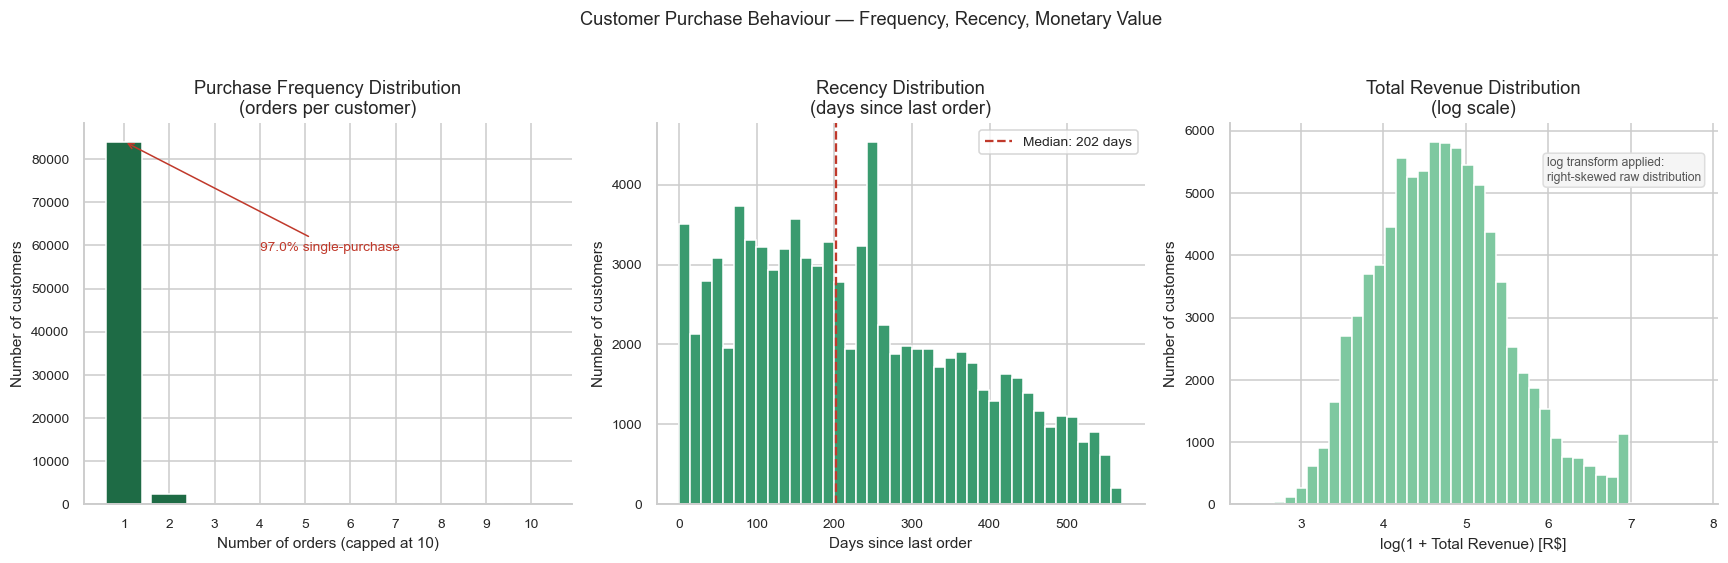

Single-purchase customers : 84,053 (97.0%)
Median total revenue      : R$107.99
Median recency            : 202 days


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Frequency distribution (capped at 10 for readability)
freq_data = cust_eda['n_orders'].clip(upper=10)
axes[0].hist(freq_data, bins=range(1, 12), color=GREEN_MID, edgecolor='white',
             align='left', rwidth=0.8)
axes[0].set_title('Purchase Frequency Distribution\n(orders per customer)')
axes[0].set_xlabel('Number of orders (capped at 10)')
axes[0].set_ylabel('Number of customers')
axes[0].set_xticks(range(1, 11))
pct_one = (cust_eda['n_orders'] == 1).mean() * 100
axes[0].annotate(f'{pct_one:.1f}% single-purchase',
                 xy=(1, (cust_eda['n_orders'] == 1).sum()),
                 xytext=(4, (cust_eda['n_orders'] == 1).sum() * 0.7),
                 arrowprops=dict(arrowstyle='->', color=ACCENT_RED),
                 fontsize=9, color=ACCENT_RED)

# Recency distribution
axes[1].hist(cust_eda['recency_days'], bins=40, color=GREEN_LIGHT, edgecolor='white')
axes[1].set_title('Recency Distribution\n(days since last order)')
axes[1].set_xlabel('Days since last order')
axes[1].set_ylabel('Number of customers')
median_rec = cust_eda['recency_days'].median()
axes[1].axvline(median_rec, color=ACCENT_RED, linestyle='--', linewidth=1.5,
                label=f'Median: {median_rec:.0f} days')
axes[1].legend(fontsize=9)

# Monetary value distribution (log scale)
axes[2].hist(np.log1p(cust_eda['total_revenue']), bins=40,
             color=GREEN_PALE, edgecolor='white')
axes[2].set_title('Total Revenue Distribution\n(log scale)')
axes[2].set_xlabel('log(1 + Total Revenue) [R$]')
axes[2].set_ylabel('Number of customers')
axes[2].annotate('log transform applied:\nright-skewed raw distribution',
                 xy=(0.65, 0.85), xycoords='axes fraction',
                 fontsize=8, color='#555555',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='#f5f5f5',
                           edgecolor='#dddddd'))

fig.suptitle('Customer Purchase Behaviour — Frequency, Recency, Monetary Value',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print(f'Single-purchase customers : {(cust_eda["n_orders"]==1).sum():,} ({pct_one:.1f}%)')
print(f'Median total revenue      : R${cust_eda["total_revenue"].median():.2f}')
print(f'Median recency            : {median_rec:.0f} days')

The three distributions reveal the structural characteristics of Olist's customer base.

**Frequency is severely right-skewed and concentrated at one.** The vast majority of customers make a single purchase and do not return. This is not unusual for a general e-commerce marketplace, Olist aggregates hundreds of independent sellers, and many customers come for a specific product rather than a platform relationship. For the BTYD model, this means the BG/NBD will need to estimate a high churn probability after the first transaction, and the Gamma-Gamma will be fitted only on the minority of customers with at least one repeat purchase.

**Recency is broadly distributed with a long right tail.** Many customers have not ordered in over a year. This is partially a structural feature of the 18-month window, customers acquired near the start of the period have simply had more time to become inactive, but the tail also reflects genuine disengagement. The recency distribution shows substantial heterogeneity in customer activity. While many customers purchased recently, a sizeable fraction have not placed an order for several months. This variation suggests that customer inactivity is likely to be an important signal in subsequent customer value modelling.

**Revenue is right-skewed and requires log transformation.** A small number of high-value customers account for a disproportionate share of total revenue. The log1p transformation applied in the Machine Learning section stabilises variance and prevents the model from over-weighting extreme outliers at the cost of accuracy for typical customers.

### **2.2 Retention and Repeat Purchase Patterns**

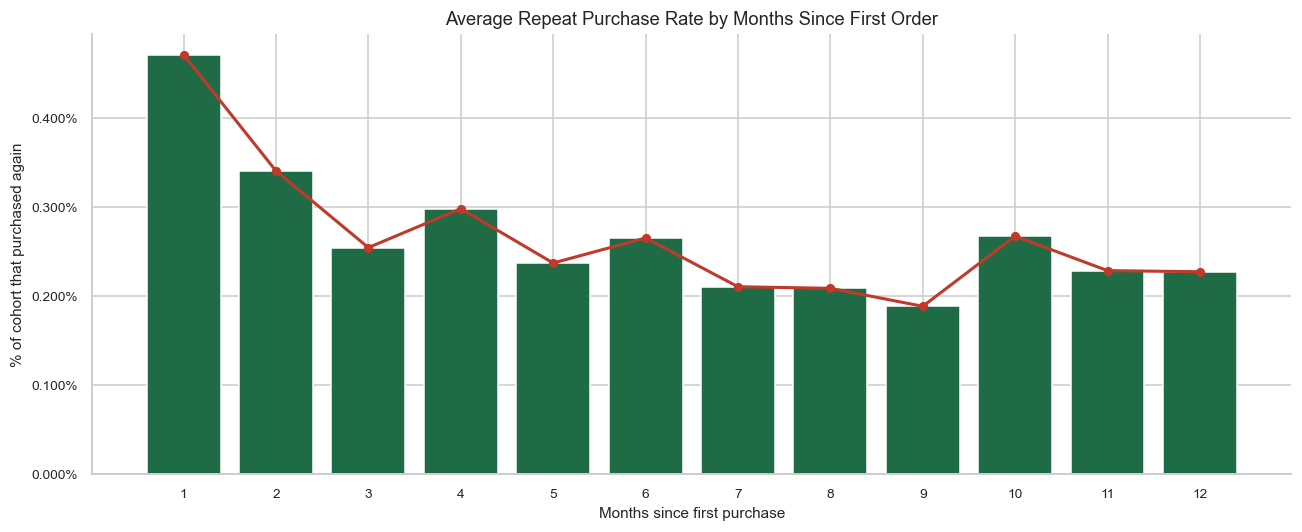

Month 1 repeat purchase rate: 0.5%
Month 3 repeat purchase rate: 0.3%


In [12]:
# Monthly cohort retention
df['cohort_month'] = df['order_purchase_timestamp'].dt.to_period('M')

first_order = (
    df.groupby('customer_unique_id')['cohort_month']
    .min()
    .reset_index()
    .rename(columns={'cohort_month': 'first_month'})
)

df = df.merge(first_order, on='customer_unique_id', how='left')

df['months_since_first'] = (
    df['cohort_month'].astype('int64') - df['first_month'].astype('int64')
)

# Cohort size
cohort_sizes = df.groupby('first_month')['customer_unique_id'].nunique()

# Active customers per cohort per month
cohort_activity = (
    df.groupby(['first_month', 'months_since_first'])['customer_unique_id']
    .nunique()
    .reset_index()
)
cohort_activity.columns = ['first_month', 'month_offset', 'active_customers']
cohort_activity['cohort_size'] = cohort_activity['first_month'].map(cohort_sizes)
cohort_activity['retention_rate'] = (
    cohort_activity['active_customers'] / cohort_activity['cohort_size']
)

# Average retention by month offset
avg_retention = (
    cohort_activity[cohort_activity['month_offset'] > 0]
    .groupby('month_offset')['retention_rate']
    .mean()
    .reset_index()
).head(12)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(avg_retention['month_offset'], avg_retention['retention_rate'] * 100,
       color=GREEN_MID, edgecolor='white')
ax.plot(avg_retention['month_offset'], avg_retention['retention_rate'] * 100,
        color=ACCENT_RED, linewidth=2, marker='o', markersize=5)
ax.set_title('Average Repeat Purchase Rate by Months Since First Order', fontsize=12)
ax.set_xlabel('Months since first purchase')
ax.set_ylabel('% of cohort that purchased again')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xticks(avg_retention['month_offset'])
plt.tight_layout()
plt.show()

m1_ret = avg_retention.iloc[0]['retention_rate'] * 100
print(f'Month 1 repeat purchase rate: {m1_ret:.1f}%')
print(f'Month 3 repeat purchase rate: {avg_retention.iloc[2]["retention_rate"]*100:.1f}%')

The cohort retention analysis confirms that repeat purchasing is relatively uncommon and declines rapidly after the first transaction. The highest probability of a second purchase occurs shortly after the initial order, after which retention stabilises at a low but persistent level. This pattern suggests that most customers interact with the marketplace in a transaction-oriented manner rather than developing a habitual purchasing relationship. Purchases are often triggered by a specific need, and once that need is satisfied, the probability of an immediate return decreases substantially.

Retention should therefore focus less on generic engagement campaigns and more on timely, context-aware communication. The most promising opportunities are likely to come from product recommendations, complementary items, and category-specific reactivation campaigns aligned with future purchasing needs.


### **2.3 Geographic Value Distribution**

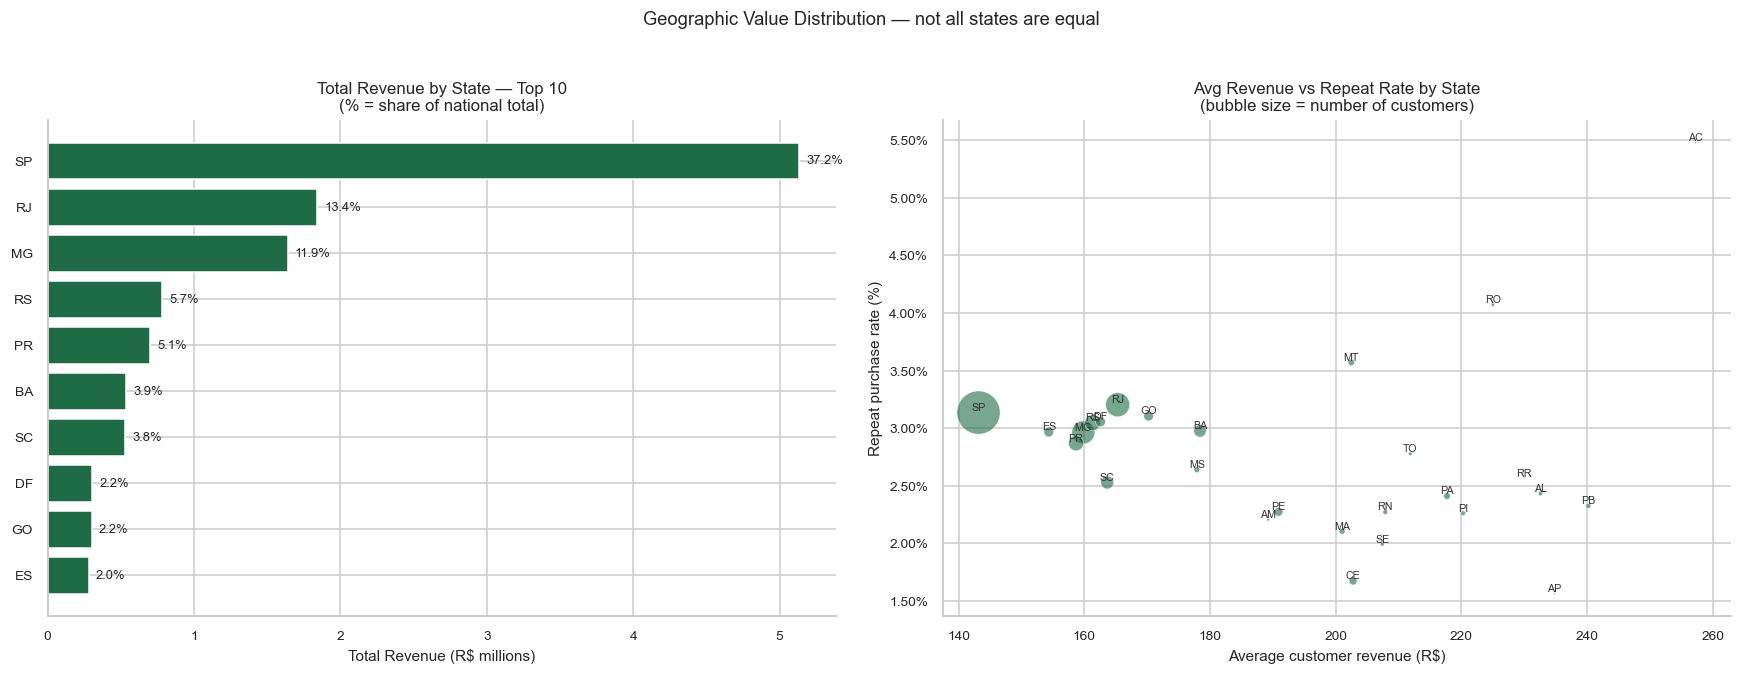

Top 3 states by revenue:
customer_state  n_customers  total_revenue  avg_revenue  repeat_rate  revenue_share_%
            SP        35842     5131444.42       143.17         0.03            37.20
            RJ        11141     1841799.72       165.32         0.03            13.40
            MG        10255     1639241.34       159.85         0.03            11.90


In [13]:
# Revenue and customer concentration by Brazilian state
state_stats = (
    cust_eda.groupby('customer_state')
    .agg(
        n_customers   = ('customer_unique_id', 'count'),
        total_revenue = ('total_revenue',      'sum'),
        avg_revenue   = ('total_revenue',      'mean'),
        repeat_rate   = ('n_orders',           lambda x: (x >= 2).mean()),
    )
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)
state_stats['revenue_share_%'] = (
    state_stats['total_revenue'] / state_stats['total_revenue'].sum() * 100
).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 states by total revenue
top10 = state_stats.head(10)
bars = axes[0].barh(top10['customer_state'][::-1],
                    top10['total_revenue'][::-1] / 1e6,
                    color=GREEN_MID, edgecolor='white')
for bar, share in zip(bars, top10['revenue_share_%'][::-1]):
    axes[0].text(bar.get_width() + 0.05,
                 bar.get_y() + bar.get_height() / 2,
                 f'{share:.1f}%', va='center', fontsize=8.5)
axes[0].set_title('Total Revenue by State — Top 10\n(% = share of national total)',
                  fontsize=11)
axes[0].set_xlabel('Total Revenue (R$ millions)')

# Avg order value vs repeat rate by state
axes[1].scatter(
    state_stats['avg_revenue'],
    state_stats['repeat_rate'] * 100,
    s=state_stats['n_customers'] / state_stats['n_customers'].max() * 800,
    color=GREEN_MID, alpha=0.6, edgecolors='white', linewidth=0.5
)
for _, row in state_stats.iterrows():
    axes[1].annotate(row['customer_state'],
                     (row['avg_revenue'], row['repeat_rate'] * 100),
                     fontsize=7, ha='center', va='bottom', color='#333333')
axes[1].set_title('Avg Revenue vs Repeat Rate by State\n(bubble size = number of customers)',
                  fontsize=11)
axes[1].set_xlabel('Average customer revenue (R$)')
axes[1].set_ylabel('Repeat purchase rate (%)')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())

fig.suptitle('Geographic Value Distribution — not all states are equal',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

top3_states = state_stats.head(3)
print('Top 3 states by revenue:')
print(top3_states[['customer_state','n_customers','total_revenue',
                    'avg_revenue','repeat_rate','revenue_share_%']].to_string(index=False))

The geographic analysis reveals a pronounced concentration of value that a uniform national marketing strategy would systematically misallocate. São Paulo (SP) and Rio de Janeiro (RJ) together account for a disproportionate share of total revenue and customer volume, consistent with their economic weight in the Brazilian economy. However, the scatter plot adds a commercially important nuance: the states with the highest average revenue per customer are not always the same as those with the highest repeat purchase rates. This creates a two-dimensional targeting opportunity, high average revenue states are the priority for CLTV maximisation campaigns, while high repeat-rate states are the priority for loyalty deepening programmes.

The geographic analysis is primarily descriptive, but it highlights meaningful differences in customer behaviour across regions. These differences provide useful business context when interpreting the CLTV estimates produced in the modelling stage.

### **2.4 RFM Feature Engineering**

The `lifetimes` library requires customer-level transaction summaries in a specific format, generated through `summary_data_from_transaction_data`. Although the resulting table resembles a traditional RFM dataset, the underlying definitions are tailored to probabilistic customer lifetime value modelling.

Two variables deserve particular attention.

First, `frequency` counts only **repeat purchases**. The initial transaction is excluded because it establishes the customer's entry into the system; the model is concerned with predicting future purchasing behaviour beyond that first order.

Second, `T` represents the customer's **observation period**: the time between their first purchase and the end of the observation window. Unlike recency, which measures how recently a customer purchased, `T` measures how long the customer has been observable. This distinction is essential, as two customers may have identical recency values but very different purchase histories depending on how long they have been active in the dataset.

Together, `frequency`, `recency`, `T`, and monetary value provide the behavioural summary required by the BG/NBD and Gamma-Gamma models used in the following sections.

In [14]:
# Build lifetimes-compatible RFM table
obs_end_date = df['order_purchase_timestamp'].max()

rfm = summary_data_from_transaction_data(
    transactions           = df,
    customer_id_col        = 'customer_unique_id',
    datetime_col           = 'order_purchase_timestamp',
    monetary_value_col     = 'payment_value',
    observation_period_end = obs_end_date,
    freq                   = 'D'
)

print(f'RFM table: {rfm.shape[0]:,} customers × {rfm.shape[1]} features')
print(f'\nColumn definitions:')
print(f'  frequency      : repeat purchases only (excludes first transaction)')
print(f'  recency        : days between first and last purchase')
print(f'  T              : days between first purchase and observation end')
print(f'  monetary_value : average revenue per REPEAT purchase')
print(f'\nCustomers with ≥1 repeat purchase: {(rfm["frequency"] >= 1).sum():,} '
      f'({(rfm["frequency"] >= 1).mean()*100:.1f}%)')
rfm.describe().T.round(2)

RFM table: 86,655 customers × 4 features

Column definitions:
  frequency      : repeat purchases only (excludes first transaction)
  recency        : days between first and last purchase
  T              : days between first purchase and observation end
  monetary_value : average revenue per REPEAT purchase

Customers with ≥1 repeat purchase: 1,829 (2.1%)


,count,mean,std,min,25%,50%,75%,max
frequency,86655.00,0.02,0.17,0.00,0.00,0.00,0.00,11.00
recency,86655.00,2.45,23.21,0.00,0.00,0.00,0.00,522.00
T,86655.00,225.31,143.94,0.00,107.00,204.00,330.00,571.00
monetary_value,86655.00,3.17,30.24,0.00,0.00,0.00,0.00,1052.43


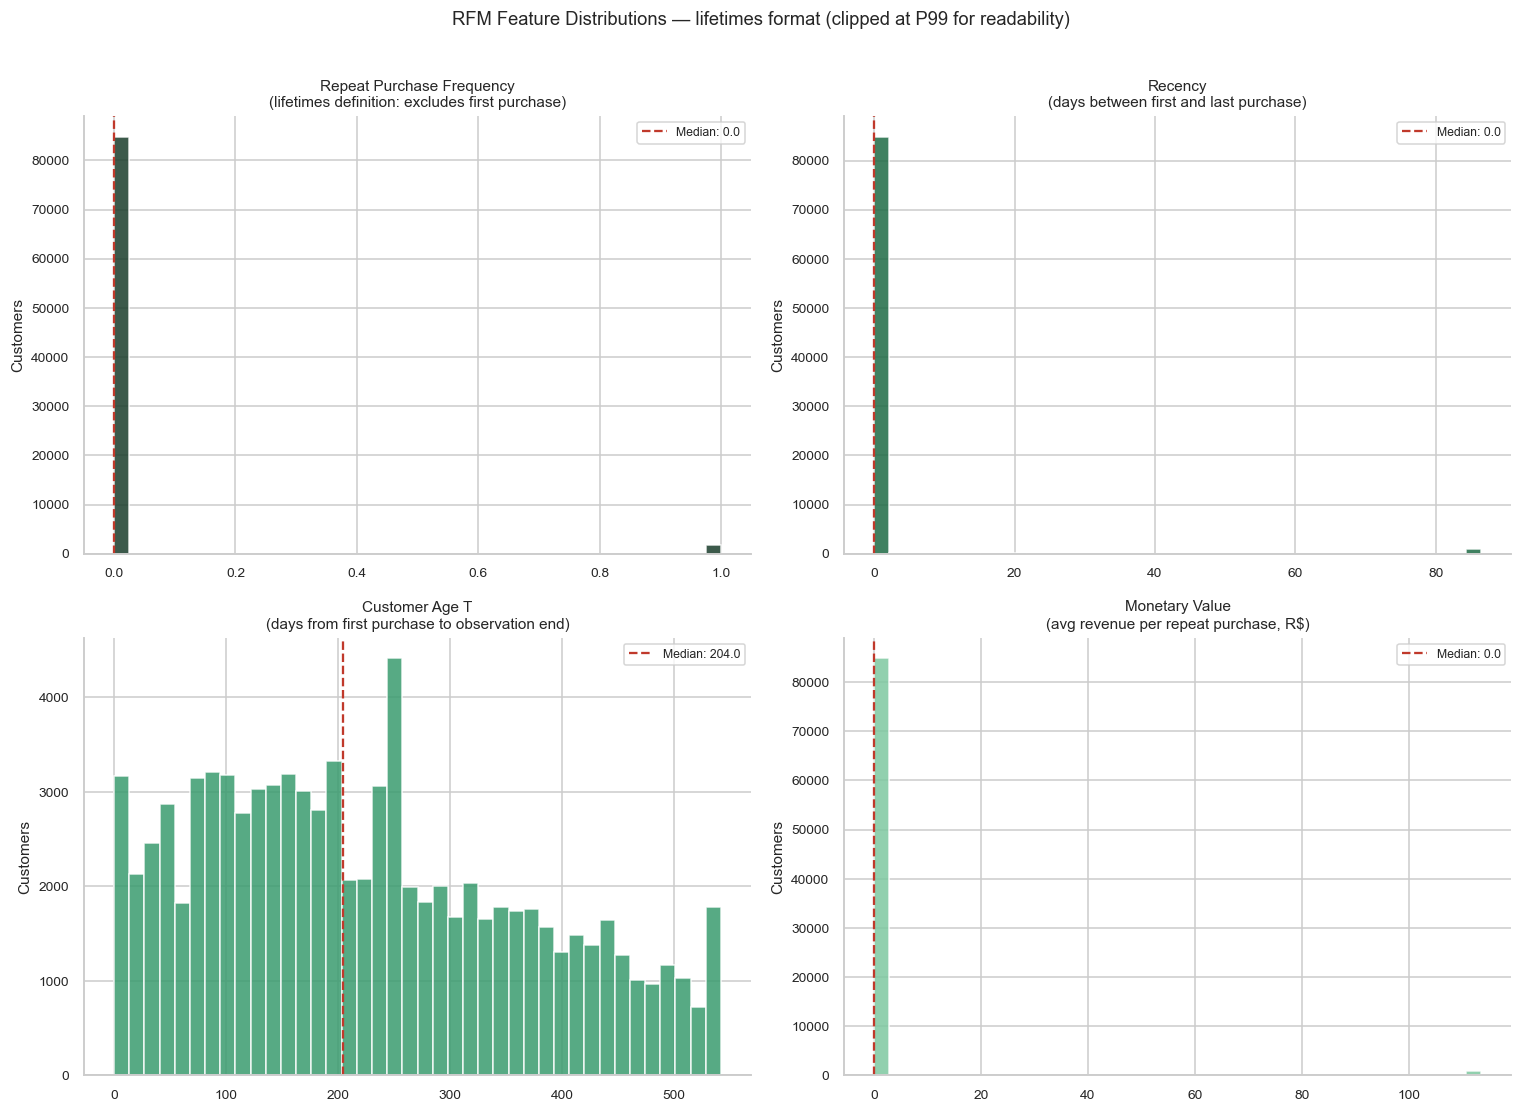

In [15]:
# Visualise RFM distributions for lifetimes-format features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

plot_specs = [
    ('frequency',      'Repeat Purchase Frequency\n(lifetimes definition: excludes first purchase)',
     GREEN_DARK),
    ('recency',        'Recency\n(days between first and last purchase)',
     GREEN_MID),
    ('T',              'Customer Age T\n(days from first purchase to observation end)',
     GREEN_LIGHT),
    ('monetary_value', 'Monetary Value\n(avg revenue per repeat purchase, R$)',
     GREEN_PALE),
]

for ax, (col, title, color) in zip(axes, plot_specs):
    data = rfm[col].clip(upper=rfm[col].quantile(0.99))
    ax.hist(data, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('Customers')
    med = rfm[col].median()
    ax.axvline(med, color=ACCENT_RED, linestyle='--', linewidth=1.5,
               label=f'Median: {med:.1f}')
    ax.legend(fontsize=8)

fig.suptitle('RFM Feature Distributions — lifetimes format (clipped at P99 for readability)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

The distributions reveal a customer base dominated by one-time purchasers. Both **frequency** and **recency** have a median of zero, indicating that most customers never make a second purchase during the observation period. Monetary value is similarly concentrated among low-spending customers, with a small number of high-value outliers generating a long right tail.

In contrast, **customer age (T)** is broadly distributed across the observation window, showing that the low repeat-purchase rate is not caused by a lack of observation time. Customers have generally been observable for long enough to repurchase; most simply do not. This finding has important modelling implications. Since almost all customers purchase only once, future customer value depends primarily on correctly identifying the small subset of customers who will return. The predictive challenge is therefore less about estimating how much customers spend and more about estimating whether they will purchase again at all.

### **2.5 EDA Summary**

Four findings from the EDA define the modelling context and the marketing strategy that follows.

**Value is concentrated and geographically structured.** São Paulo and Rio de Janeiro together account for the majority of total revenue and customer volume. The scatter plot of average revenue versus repeat rate reveals that states with higher customer value do not necessarily exhibit higher repeat purchasing behaviour.

**The customer base is predominantly single-purchase.** The vast majority of customers make exactly one observed purchase during the observation window. This is not necessarily evidence of dissatisfaction; rather, it reflects the marketplace nature of Olist, where many customers arrive to satisfy a specific purchasing need rather than to build an ongoing relationship with the platform. The Gamma-Gamma model will therefore be fitted only on the minority of repeat buyers, while the ML model must address the large concentration of customers with no future observed revenue.

**Repeat purchase rates stabilise quickly at a low but persistent level.** After an initial decline following the first purchase, cohort-level repeat purchasing stabilises. Although the overall repeat rate remains low, the existence of a persistent repeat-purchase segment suggests that a subset of customers develops a longer-term relationship with the platform. Identifying and valuing these customers is one of the primary objectives of the CLTV models developed in the next section.

**Revenue distributions are right-skewed and require transformation.** Both total revenue and average order value exhibit long right tails, with a small number of customers generating disproportionately high spending. The ML framework therefore applies a log1p transformation to the target variable to reduce the influence of extreme observations on the optimisation process. The BTYD framework is less affected by this issue because its probabilistic assumptions are designed to accommodate skewed spending behaviour directly.

## 3. Modeling and Evaluation

The EDA established three structural facts about Olist's customer base: 97% of customers make a single purchase and do not return, repeat purchase rates stabilise at a low but persistent level after month one, and value is geographically concentrated in a small number of states. Each of these facts directly shapes the modelling strategy.

Two frameworks are developed in parallel. The probabilistic BTYD approach treats customer behaviour as a stochastic process, it models the *distribution* of purchasing rates across the customer base and infers, for each individual, the probability of being active and the expected number of future transactions. The machine learning approach treats CLTV prediction as a supervised regression problem, it uses features engineered from the calibration period to predict holdout revenue directly, without distributional assumptions.

Neither framework dominates unconditionally. Their comparison in Section 3.3 is a decision framework that maps each model's strengths to a specific business use case:

| Framework | Best suited for | Limitation |
|---|---|---|
| **BTYD (BG/NBD + Gamma-Gamma)** | Macro financial planning: total base value, budget forecasting | Less accurate for individual-level predictions on the majority of typical customers |
| **ML Regressor (XGBoost)** | Micro targeting, ranking individual customers for campaign prioritisation | Sensitive to the zero-inflation problem (97% single buyers) without explicit handling |

### 3.1 Probabilistic Modeling, BTYD Framework

The Buy Till You Die (BTYD) family of models was specifically designed for non-contractual settings: marketplaces, retail, and e-commerce platforms where customers can purchase at any time and may silently disengage without any observable cancellation event. This is precisely the Olist context: a customer who stops purchasing is indistinguishable, at observation time, from a customer who simply has not yet made their next purchase.

Two models are combined. The **BG/NBD model** (Beta-Geometric / Negative Binomial Distribution) models two simultaneous processes: a Poisson purchase process while the customer is active, and a geometric dropout process where the customer may permanently churn after each transaction. The **Gamma-Gamma model** is then layered on top to estimate the expected monetary value of each future transaction, conditional on the customer making at least one repeat purchase.

The pipeline follows the calibration/holdout structure required for valid model evaluation: the BG/NBD is fitted on the calibration period, its frequency predictions are validated against actual holdout purchases, and the final CLTV is calculated as the product of expected future transactions and expected transaction value over a 3-month horizon.

#### 3.1.1 Calibration / Holdout Split

In [16]:
# Observation period boundaries
MAX_DATE           = df['order_purchase_timestamp'].max()
HOLDOUT_DAYS       = 90    # 3-month holdout = one fiscal quarter
CALIBRATION_END    = MAX_DATE - timedelta(days=HOLDOUT_DAYS)

print(f'Observation end    : {MAX_DATE.date()}')
print(f'Calibration end    : {CALIBRATION_END.date()}')
print(f'Holdout start      : {(CALIBRATION_END + timedelta(days=1)).date()}')
print(f'Holdout period     : {HOLDOUT_DAYS} days (1 fiscal quarter)')

# Build calibration/holdout RFM table using lifetimes utility
df_cal_holdout = calibration_and_holdout_data(
    df,
    customer_id_col        = 'customer_unique_id',
    datetime_col           = 'order_purchase_timestamp',
    monetary_value_col     = 'payment_value',
    observation_period_end = MAX_DATE,
    calibration_period_end = CALIBRATION_END,
    freq                   = 'D'
)

print(f'\nCalibration/holdout table: {len(df_cal_holdout):,} customers')
print(f'Columns: {list(df_cal_holdout.columns)}')
df_cal_holdout.head()

Observation end    : 2018-07-30
Calibration end    : 2018-05-01
Holdout start      : 2018-05-02
Holdout period     : 90 days (1 fiscal quarter)

Calibration/holdout table: 68,868 customers
Columns: ['frequency_cal', 'recency_cal', 'T_cal', 'monetary_value_cal', 'frequency_holdout', 'monetary_value_holdout', 'duration_holdout']


,frequency_cal,recency_cal,T_cal,monetary_value_cal,frequency_holdout,monetary_value_holdout,duration_holdout
customer_unique_id,,,,,,,
0000f46a3911fa3c0805444483337064,0.00,0.00,417.00,0.00,0.00,0.00,90.00
0000f6ccb0745a6a4b88665a16c9f078,0.00,0.00,201.00,0.00,0.00,0.00,90.00
0004aac84e0df4da2b147fca70cf8255,0.00,0.00,168.00,0.00,0.00,0.00,90.00
0004bd2a26a76fe21f786e4fbd80607f,0.00,0.00,26.00,0.00,0.00,0.00,90.00
00050ab1314c0e55a6ca13cf7181fecf,0.00,0.00,11.00,0.00,0.00,0.00,90.00


In [17]:
# Separate datasets for BG/NBD and Gamma-Gamma
# BG/NBD can use all customers, including customers with zero repeat purchases.
# Gamma-Gamma requires repeat purchases and positive monetary value.
btyd_all = df_cal_holdout.copy()

gg_data = btyd_all[
    (btyd_all['frequency_cal'] >= 1) &
    (btyd_all['monetary_value_cal'] > 0)
].copy()

print(f'Customers available for BG/NBD modelling: {len(btyd_all):,}')
print(f'Customers retained for Gamma-Gamma modelling: {len(gg_data):,}')
print(f'Excluded from Gamma-Gamma only: {len(btyd_all) - len(gg_data):,}')

print(f'\nShare excluded from Gamma-Gamma: {(len(btyd_all) - len(gg_data)) / len(btyd_all) * 100:.1f}%')
print('These customers made no repeat purchase in calibration, so their average repeat-purchase monetary value cannot be estimated.')
print('They remain informative for BG/NBD because zero repeat frequency contributes to dropout and purchase-rate estimation.')

Customers available for BG/NBD modelling: 68,868
Customers retained for Gamma-Gamma modelling: 1,301
Excluded from Gamma-Gamma only: 67,567

Share excluded from Gamma-Gamma: 98.1%
These customers made no repeat purchase in calibration, so their average repeat-purchase monetary value cannot be estimated.
They remain informative for BG/NBD because zero repeat frequency contributes to dropout and purchase-rate estimation.


The calibration/holdout table is used differently by the two components of the BTYD framework. The BG/NBD model is fitted on the full customer base, including customers with zero repeat purchases. In the lifetimes formulation, frequency_cal counts only repeat purchases, meaning that a customer with frequency_cal = 0 has made exactly one purchase during the calibration period. These customers remain informative because their lack of repeat activity contributes to the estimation of purchase rates and dropout probabilities.

The Gamma-Gamma monetary model imposes a stricter requirement. Since it estimates average spending conditional on repeat purchasing, it can only be fitted on customers with at least one repeat purchase (frequency_cal ≥ 1) and positive monetary value. Customers who purchased only once therefore remain part of the BG/NBD estimation but are excluded from the monetary component of the framework.

After the calibration split, 68,868 customers are available for BG/NBD modelling. The BG/NBD framework can incorporate customers with zero repeat purchases because the absence of repeat behaviour is itself informative about purchase rates and dropout probabilities.

However, only 1,301 customers (1.9%) exhibit at least one repeat purchase and therefore satisfy the requirements of the Gamma-Gamma monetary model. The remaining 98.1% cannot contribute to monetary-value estimation because their average repeat-purchase spend is undefined.

This result is consistent with the EDA findings, which showed that Olist's customer base is overwhelmingly composed of one-time purchasers. It also highlights an important limitation of probabilistic CLTV modelling in this dataset: reliable monetary estimation is possible only for a very small subset of customers who demonstrate repeat purchasing behaviour.

#### 3.1.2 BG/NBD Model: Purchase Frequency and Alive Probability

In [18]:
# Fit BG/NBD model on all calibration customers
bgf = BetaGeoFitter(penalizer_coef=0.001)

bgf.fit(
    btyd_all['frequency_cal'],
    btyd_all['recency_cal'],
    btyd_all['T_cal']
)

print('BG/NBD Model — Fitted Parameters:')
print(bgf.summary.round(4))

BG/NBD Model — Fitted Parameters:
       coef  se(coef)  lower 95% bound  upper 95% bound
r      0.02      0.00             0.01             0.02
alpha 77.40      9.52            58.74            96.07
a      0.29      0.06             0.18             0.41
b      0.06      0.01             0.03             0.09


The four fitted parameters characterise the entire customer base as two distributions.

**Purchase rate parameters: $r$ and $α$.** Together these define a Gamma distribution of individual transaction rates across the population. The ratio $r/α$ represents the average purchase rate while a customer is active. A high $α$ relative to $r$ indicates a low average purchase rate, active Olist customers purchase infrequently, consistent with the marketplace's product mix of durable goods (electronics, home furnishings) rather than consumables.

**Dropout parameters: $a$ and $b$.** These define a Beta distribution of dropout probabilities. The ratio $a/(a+b)$ represents the average dropout probability after each transaction. The parameters $a$ and $b$ govern the distribution of dropout probabilities across customers. Their estimated values indicate a customer base characterised by high post-purchase attrition, consistent with the EDA finding that most customers purchase only once. At the same time, the Beta distribution allows dropout risk to vary across individuals, which motivates the use of customer-specific alive probabilities rather than a single population-level retention estimate.

The standard errors and confidence intervals confirm stable parameter estimation, no parameter has a confidence interval that spans zero, indicating that the model has sufficient signal to identify meaningful behavioural heterogeneity in this customer base.

In [19]:
# Predict expected purchases in holdout period for all BG/NBD customers
btyd_all['predicted_purchases'] = bgf.predict(
    btyd_all['duration_holdout'],
    btyd_all['frequency_cal'],
    btyd_all['recency_cal'],
    btyd_all['T_cal']
)

# Compute alive probability for each customer
btyd_all['prob_alive'] = bgf.conditional_probability_alive(
    btyd_all['frequency_cal'],
    btyd_all['recency_cal'],
    btyd_all['T_cal']
)

print('BG/NBD Predictions — summary:')
print(f"  Avg predicted purchases (holdout) : {btyd_all['predicted_purchases'].mean():.3f}")
print(f"  Avg actual purchases (holdout)    : {btyd_all['frequency_holdout'].mean():.3f}")
print(f"  Avg alive probability             : {btyd_all['prob_alive'].mean():.3f}")
print(f"  Customers with prob_alive > 0.5   : {(btyd_all['prob_alive'] > 0.5).sum():,}")

BG/NBD Predictions — summary:
  Avg predicted purchases (holdout) : 0.008
  Avg actual purchases (holdout)    : 0.007
  Avg alive probability             : 0.984
  Customers with prob_alive > 0.5   : 67,641


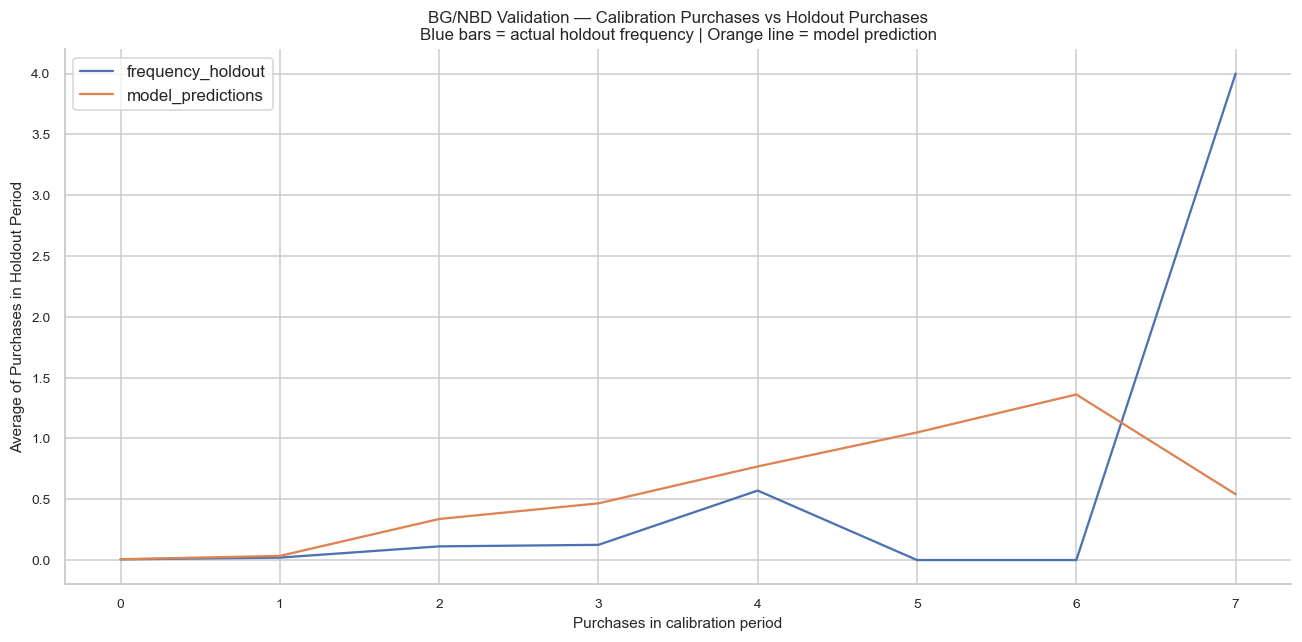

In [20]:
# Calibration vs holdout validation plot
fig, ax = plt.subplots(figsize=(12, 6))
plot_calibration_purchases_vs_holdout_purchases(
    bgf, df_cal_holdout,
    n=10,
    ax=ax
)
ax.set_title(
    'BG/NBD Validation — Calibration Purchases vs Holdout Purchases\n'
    'Blue bars = actual holdout frequency | Orange line = model prediction',
    fontsize=11
)
# Restyle to match palette
for patch in ax.patches:
    patch.set_facecolor(GREEN_MID)
    patch.set_alpha(0.7)
plt.tight_layout()
plt.show()

The model captures the qualitative relationship between past and future purchasing behaviour: customers with more calibration purchases are generally predicted to purchase more during the holdout period. Quantitatively, however, predictions become unstable in the highest-frequency groups because these customers are extremely rare. The validation should therefore be interpreted primarily as evidence that the model captures the overall behavioural trend rather than as precise estimation for the most active customers.

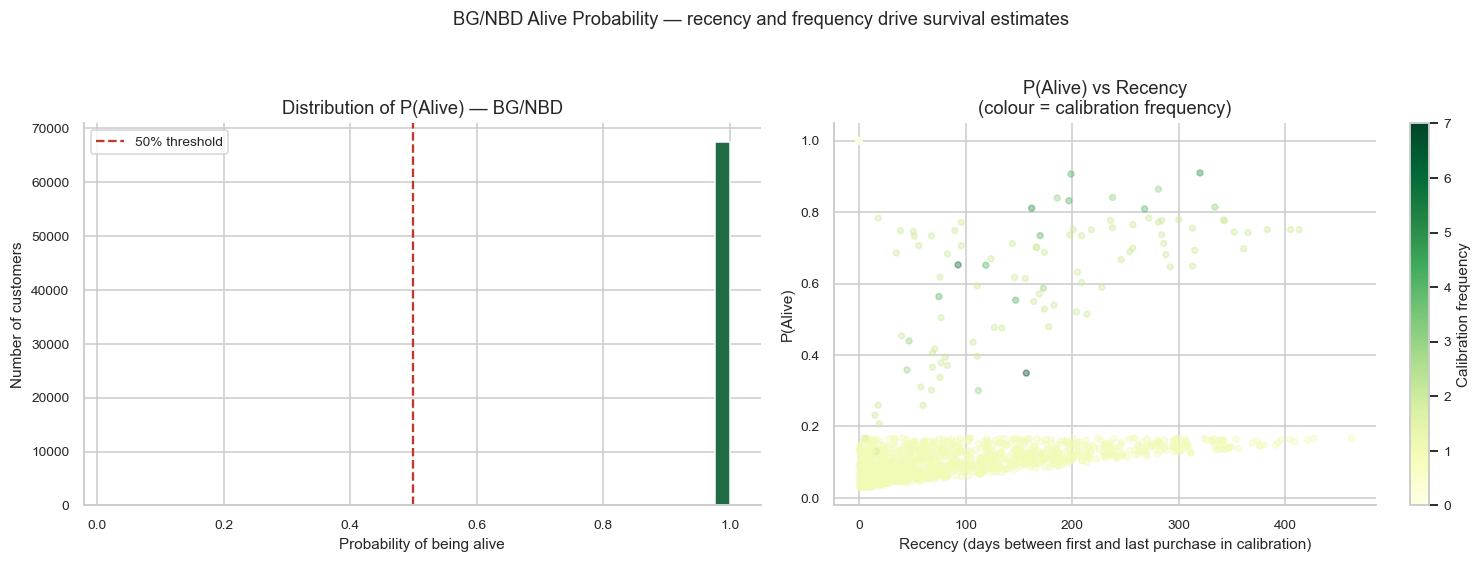

In [21]:
# Alive probability distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of alive probabilities
axes[0].hist(btyd_all['prob_alive'], bins=40,
             color=GREEN_MID, edgecolor='white')
axes[0].axvline(0.5, color=ACCENT_RED, linestyle='--', linewidth=1.5,
                label='50% threshold')
axes[0].set_title('Distribution of P(Alive) — BG/NBD')
axes[0].set_xlabel('Probability of being alive')
axes[0].set_ylabel('Number of customers')
axes[0].legend(fontsize=9)

# Alive probability vs recency
axes[1].scatter(
    btyd_all['recency_cal'],
    btyd_all['prob_alive'],
    c=btyd_all['frequency_cal'],
    cmap='YlGn', alpha=0.4, s=15
)
axes[1].set_title('P(Alive) vs Recency\n(colour = calibration frequency)')
axes[1].set_xlabel('Recency (days between first and last purchase in calibration)')
axes[1].set_ylabel('P(Alive)')

sm = plt.cm.ScalarMappable(
    cmap='YlGn',
    norm=plt.Normalize(
        btyd_all['frequency_cal'].min(),
        btyd_all['frequency_cal'].max()
    )
)
plt.colorbar(sm, ax=axes[1], label='Calibration frequency')

fig.suptitle('BG/NBD Alive Probability — recency and frequency drive survival estimates',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

The alive-probability plot illustrates the central logic of the BG/NBD model. Customers with more repeat purchases and longer purchasing histories generally receive higher survival estimates because repeated transactions provide evidence of continued engagement. In contrast, customers with little or no repeat activity receive substantially lower alive probabilities, reflecting the model's belief that they are more likely to have dropped out.

An important observation is that the average alive probability remains very high (98.4%) despite the low repeat-purchase rate observed in the EDA. This is a characteristic of non-contractual settings: the model cannot directly observe churn and therefore treats many inactive customers as potentially still alive. The probability should therefore be interpreted as the likelihood that a customer remains capable of purchasing again, not as a guarantee that they will return.

This is the operationally critical output of the BG/NBD model. While aggregate purchase forecasts support financial planning, the individual alive probability provides a customer-level indicator of future engagement. Combined with predicted CLTV, it enables the identification of valuable customers whose future revenue may be at risk and therefore supports prioritised retention and win-back actions.

#### 3.1.3 Gamma-Gamma Model: Expected Monetary Value

In [22]:
corr = gg_data['frequency_cal'].corr(gg_data['monetary_value_cal'])
print(f'Pearson correlation — frequency vs monetary value: {corr:.4f}')

Pearson correlation — frequency vs monetary value: -0.0027


Before fitting the Gamma-Gamma model, its key assumption must be verified: average transaction value should be independent of purchase frequency. The Pearson correlation between calibration frequency and average monetary value is -0.0027, effectively zero. This indicates that customers who purchase more frequently do not systematically spend more or less per transaction than customers who purchase less frequently. The independence assumption therefore appears reasonable for the Olist dataset and supports the use of the Gamma-Gamma framework.

In [23]:
ggf = GammaGammaFitter(penalizer_coef=0.01)

ggf.fit(
    gg_data['frequency_cal'],
    gg_data['monetary_value_cal']
)

print('Gamma-Gamma Model — Fitted Parameters:')
print(ggf.summary.round(4))

Gamma-Gamma Model — Fitted Parameters:
   coef  se(coef)  lower 95% bound  upper 95% bound
p  4.13      0.14             3.86             4.40
q  0.50      0.02             0.47             0.53
v  3.85      0.14             3.58             4.13


The Gamma-Gamma model produces three parameters ($p$, $q$, and $v$) that describe how spending behaviour varies across customers. Rather than predicting whether a customer will purchase again, the model estimates how much revenue a future transaction is expected to generate, conditional on the customer remaining active.

The fitted parameters indicate substantial heterogeneity in spending behaviour, consistent with the right-skewed monetary distributions observed during the EDA. Most customers generate relatively modest transaction values, while a small subset contributes disproportionately large purchases. The Gamma-Gamma framework captures this variation and converts future purchase forecasts from the BG/NBD model into monetary value forecasts.

The key model assumption, that monetary value is independent of purchase frequency, was verified in the correlation check above. A customer who purchases ten times is not expected to spend systematically more or less per transaction than one who purchases twice. This is empirically plausible for a marketplace like Olist, where purchases correspond to independent product needs rather than recurring subscriptions or usage-based services. Under this assumption, purchase frequency and spending can be modelled separately and then combined to estimate future customer value.

#### 3.1.4 CLTV Calculation: 3-Month Horizon

In [24]:
gg_data['cltv_3m_btyd'] = ggf.customer_lifetime_value(
    bgf,
    gg_data['frequency_cal'],
    gg_data['recency_cal'],
    gg_data['T_cal'],
    gg_data['monetary_value_cal'],
    time=3,
    freq='D',
    discount_rate=0.01
)

gg_data['predicted_purchases'] = bgf.predict(
    gg_data['duration_holdout'],
    gg_data['frequency_cal'],
    gg_data['recency_cal'],
    gg_data['T_cal']
)

gg_data['prob_alive'] = bgf.conditional_probability_alive(
    gg_data['frequency_cal'],
    gg_data['recency_cal'],
    gg_data['T_cal']
)

gg_data['cltv_actual'] = (
    gg_data['frequency_holdout'] *
    gg_data['monetary_value_holdout']
)

print('3-Month CLTV — BTYD Predictions:')
print(f"  Mean predicted CLTV  : R${gg_data['cltv_3m_btyd'].mean():.2f}")
print(f"  Median predicted CLTV: R${gg_data['cltv_3m_btyd'].median():.2f}")
print(f"  Total repeat-buyer value (3m): R${gg_data['cltv_3m_btyd'].sum():,.0f}")

print(f"\n  Mean actual revenue  : R${gg_data['cltv_actual'].mean():.2f}")
print(f"  Total actual revenue : R${gg_data['cltv_actual'].sum():,.0f}")

3-Month CLTV — BTYD Predictions:
  Mean predicted CLTV  : R$9.90
  Median predicted CLTV: R$3.60
  Total repeat-buyer value (3m): R$12,878

  Mean actual revenue  : R$6.17
  Total actual revenue : R$8,030


The 3-month CLTV estimate is computed for the repeat-buyer segment only, because the Gamma-Gamma monetary model requires customers with at least one repeat purchase and positive monetary value. Therefore, the predicted value below should not be interpreted as the total value of the entire Olist customer base, but as the predicted 3-month value of customers for whom repeat-purchase monetary behaviour is observable.

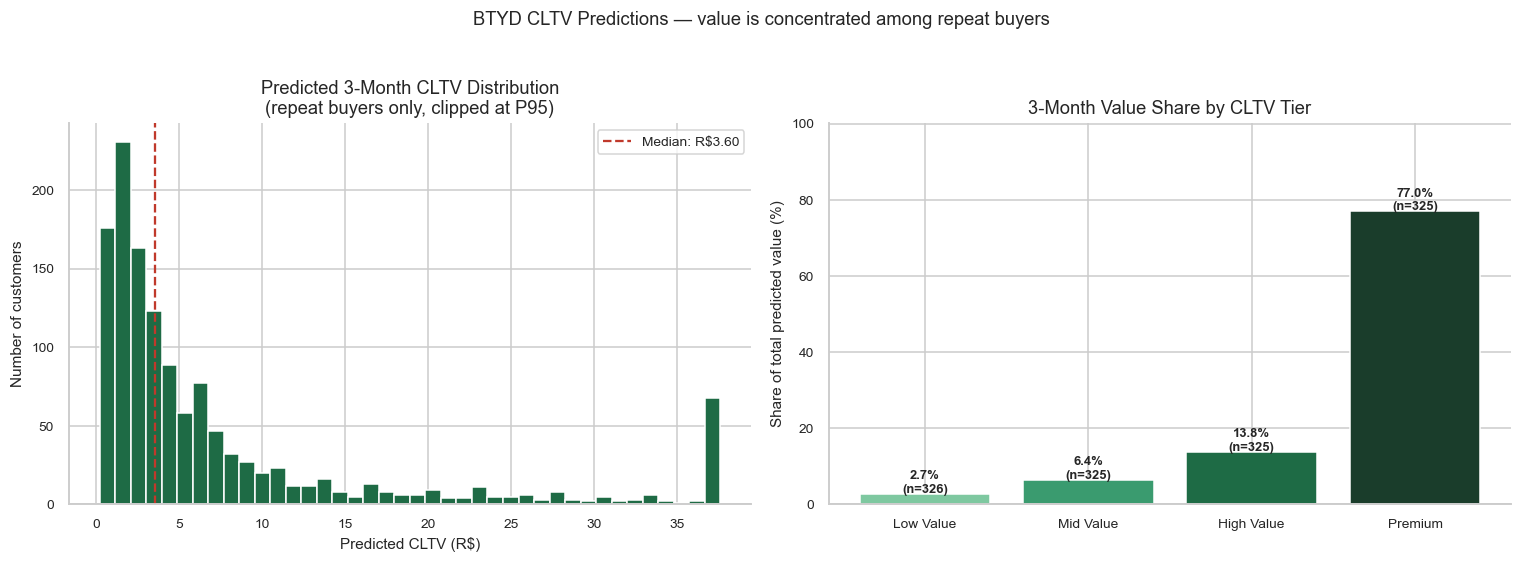


CLTV Tier Summary:
            n_customers  avg_cltv  avg_prob_alive  total_value  value_share_%
cltv_tier                                                                    
Low Value           326      1.08            0.07       350.99           2.70
Mid Value           325      2.56            0.10       830.44           6.40
High Value          325      5.46            0.12      1775.84          13.80
Premium             325     30.53            0.27      9921.02          77.00


In [25]:
# CLTV distribution and CLTV tier segmentation
# CLTV is computed only for customers valid for Gamma-Gamma estimation

gg_data['cltv_tier'] = pd.qcut(
    gg_data['cltv_3m_btyd'],
    q=4,
    labels=['Low Value', 'Mid Value', 'High Value', 'Premium']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CLTV distribution
cltv_p95 = gg_data['cltv_3m_btyd'].quantile(0.95)

axes[0].hist(
    gg_data['cltv_3m_btyd'].clip(upper=cltv_p95),
    bins=40,
    color=GREEN_MID,
    edgecolor='white'
)

median_cltv = gg_data['cltv_3m_btyd'].median()

axes[0].axvline(
    median_cltv,
    color=ACCENT_RED,
    linestyle='--',
    linewidth=1.5,
    label=f'Median: R${median_cltv:.2f}'
)

axes[0].set_title('Predicted 3-Month CLTV Distribution\n(repeat buyers only, clipped at P95)')
axes[0].set_xlabel('Predicted CLTV (R$)')
axes[0].set_ylabel('Number of customers')
axes[0].legend(fontsize=9)

# CLTV tier summary
tier_summary = (
    gg_data.groupby('cltv_tier', observed=True)
    .agg(
        n_customers    = ('cltv_3m_btyd', 'count'),
        avg_cltv       = ('cltv_3m_btyd', 'mean'),
        avg_prob_alive = ('prob_alive', 'mean'),
        total_value    = ('cltv_3m_btyd', 'sum')
    )
)

tier_summary['value_share_%'] = (
    tier_summary['total_value'] / tier_summary['total_value'].sum() * 100
).round(1)

tier_colors = [GREEN_PALE, GREEN_LIGHT, GREEN_MID, GREEN_DARK]

bars = axes[1].bar(
    tier_summary.index,
    tier_summary['value_share_%'],
    color=tier_colors,
    edgecolor='white'
)

for bar, (_, row) in zip(bars, tier_summary.iterrows()):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{row['value_share_%']:.1f}%\n(n={int(row['n_customers']):,})",
        ha='center',
        fontsize=8.5,
        fontweight='bold'
    )

axes[1].set_title('3-Month Value Share by CLTV Tier')
axes[1].set_ylabel('Share of total predicted value (%)')
axes[1].set_ylim(0, tier_summary['value_share_%'].max() * 1.3)

fig.suptitle(
    'BTYD CLTV Predictions — value is concentrated among repeat buyers',
    fontsize=12,
    y=1.02
)

plt.tight_layout()
plt.show()

print('\nCLTV Tier Summary:')
print(tier_summary.round(2).to_string())

The CLTV distribution and tier analysis show that predicted value is highly concentrated within the repeat-buyer segment. The distribution is strongly right-skewed: most repeat buyers have low predicted 3-month value, while a small Premium tier accounts for 77.0% of total predicted value.

This concentration is commercially important. Even within the already small repeat-buyer population, not all customers deserve the same retention investment. The Premium tier has both the highest average CLTV (R$30.53) and the highest average alive probability (0.27), suggesting that these customers are the most valuable group to protect.

The tier-level alive probability adds a second decision layer. High-CLTV customers with relatively high alive probability should be prioritised for retention and loyalty reinforcement, while high-CLTV customers with low alive probability represent potential win-back candidates. This two-dimensional logic, value combined with survival probability, is the basis for the targeting strategy in Section 4.

In [26]:
# Win-back candidate identification
# High CLTV among repeat buyers + below-median alive probability

cltv_threshold = gg_data['cltv_3m_btyd'].quantile(0.75)
alive_threshold = gg_data['prob_alive'].median()

winback = gg_data[
    (gg_data['cltv_3m_btyd'] >= cltv_threshold) &
    (gg_data['prob_alive'] <= alive_threshold)
].copy()

print('# Win-back candidates: high predicted CLTV among repeat buyers + below-median alive probability:')
print(f'  Count                  : {len(winback):,}')
print(f'  Avg predicted CLTV     : R${winback["cltv_3m_btyd"].mean():.2f}')
print(f'  Avg alive probability  : {winback["prob_alive"].mean():.3f}')
print(f'  Total at-risk value    : R${winback["cltv_3m_btyd"].sum():,.0f}')

print(f'\n  CLTV threshold (P75)   : R${cltv_threshold:.2f}')
print(f'  Alive threshold (P50)  : {alive_threshold:.3f}')

# Win-back candidates: high predicted CLTV among repeat buyers + below-median alive probability:
  Count                  : 53
  Avg predicted CLTV     : R$14.72
  Avg alive probability  : 0.086
  Total at-risk value    : R$780

  CLTV threshold (P75)   : R$8.02
  Alive threshold (P50)  : 0.105


The CLTV × alive probability filter identifies 53 win-back candidates: repeat buyers with predicted CLTV above the 75th percentile and alive probability below the median. These customers have an average predicted 3-month CLTV of R$14.72, an average alive probability of 0.086, and together represent R$780 of at-risk predicted value.

This segment is small but strategically meaningful. It does not justify a broad reactivation campaign, but it does justify a highly targeted win-back programme focused on customers who have demonstrated repeat-purchase value yet now show weaker survival signals. The appropriate intervention is personalised and selective: tailored category recommendations, service-led outreach, or loyalty reinforcement, rather than generic mass discounts.

#### 3.1.5 BG/NBD Evaluation: Predicted vs Actual Frequency

In [27]:
# Score function for MAE, MSE, RMSE
def score_model(actuals, predicted, metric='mse'):
    actuals = np.asarray(actuals)
    predicted = np.asarray(predicted)
    
    metric = metric.lower()
    
    if metric == 'mse':
        return np.mean((actuals - predicted) ** 2)
    elif metric == 'rmse':
        return np.sqrt(np.mean((actuals - predicted) ** 2))
    elif metric == 'mae':
        return np.mean(np.abs(actuals - predicted))
    else:
        raise ValueError("metric must be one of: 'mse', 'rmse', 'mae'")


# BG/NBD frequency-level evaluation on all calibration/holdout customers
freq_actual = btyd_all['frequency_holdout']
freq_predicted = btyd_all['predicted_purchases']

btyd_freq_mse = score_model(freq_actual, freq_predicted, 'mse')
btyd_freq_rmse = score_model(freq_actual, freq_predicted, 'rmse')
btyd_freq_mae = score_model(freq_actual, freq_predicted, 'mae')


# BTYD CLTV-level evaluation on Gamma-Gamma eligible repeat buyers only
cltv_actual = gg_data['cltv_actual']
cltv_predicted = gg_data['cltv_3m_btyd']

btyd_cltv_mse = score_model(cltv_actual, cltv_predicted, 'mse')
btyd_cltv_rmse = score_model(cltv_actual, cltv_predicted, 'rmse')
btyd_cltv_mae = score_model(cltv_actual, cltv_predicted, 'mae')


print('BG/NBD — Frequency Prediction Metrics (holdout, all customers):')
print(f'  MSE  : {btyd_freq_mse:.4f}')
print(f'  RMSE : {btyd_freq_rmse:.4f}')
print(f'  MAE  : {btyd_freq_mae:.4f}')

print('\nBTYD — CLTV Prediction Metrics (holdout, repeat buyers only):')
print(f'  MSE  : {btyd_cltv_mse:.2f}')
print(f'  RMSE : {btyd_cltv_rmse:.2f}')
print(f'  MAE  : {btyd_cltv_mae:.2f}')

BG/NBD — Frequency Prediction Metrics (holdout, all customers):
  MSE  : 0.0071
  RMSE : 0.0842
  MAE  : 0.0138

BTYD — CLTV Prediction Metrics (holdout, repeat buyers only):
  MSE  : 3689.30
  RMSE : 60.74
  MAE  : 14.58


### 3.2 Machine Learning Approach: XGBoost Regressor

The BTYD framework is well suited to modelling purchase timing in a non-contractual setting, and the BG/NBD component can incorporate the full customer base, including customers with zero repeat purchases. However, the monetary CLTV component based on Gamma-Gamma can only be estimated for customers with repeat-purchase monetary history. This limits the direct monetary CLTV estimation to a small repeat-buyer segment.

The machine learning approach addresses this limitation directly. Rather than modelling the purchasing process through distributional assumptions, it treats future customer value as a supervised regression problem: given features computed from the calibration period, predict the revenue a customer will generate in the holdout period. This allows the model to include the full customer base, including single-purchase customers whose holdout revenue is zero.

Two design choices shape the ML pipeline:

**Log1p transformation of the target variable.** Holdout revenue is severely right-skewed and zero-inflated. Without transformation, the model would optimise its loss function primarily on the small number of high-spending customers, producing poor predictions for the typical customer. The log1p transformation compresses the scale of large values while preserving the ordering, and handles zero-revenue customers without requiring a separate classification step.

**Full customer base scope.** Unlike the BTYD sample, the ML model is trained and evaluated on all customers, including single-purchase buyers with zero holdout revenue. This produces a more conservative and more realistic performance estimate, and makes the ML CLTV scores directly comparable across the entire customer base rather than only the repeat-purchase minority.

#### 3.2.1 Feature Engineering: Calibration Period

In [29]:
# Build calibration and holdout transaction subsets
df_calib   = df[df['order_purchase_timestamp'] <= CALIBRATION_END].copy()
df_holdout = df[df['order_purchase_timestamp'] >  CALIBRATION_END].copy()

# Calibration features: customer-level aggregation
calib_features = (
    df_calib.groupby('customer_unique_id')
    .agg(
        frequency_cal    = ('order_id',                'nunique'),
        total_rev_cal    = ('payment_value',           'sum'),
        aov_cal          = ('payment_value',           'mean'),
        n_items_cal      = ('n_items',                 'mean'),
        avg_review_cal   = ('review_score',            'mean'),
        first_order_cal  = ('order_purchase_timestamp','min'),
        last_order_cal   = ('order_purchase_timestamp','max'),
    )
    .reset_index()
)

# Derived time features
calib_features['recency_cal']     = (
    CALIBRATION_END - calib_features['last_order_cal']
).dt.days
calib_features['tenure_cal']      = (
    calib_features['last_order_cal'] - calib_features['first_order_cal']
).dt.days

# Holdout target: actual revenue per customer in holdout period
holdout_revenue = (
    df_holdout.groupby('customer_unique_id')['payment_value']
    .sum()
    .reset_index()
    .rename(columns={'payment_value': 'holdout_revenue'})
)

# Merge features with target: left join keeps all calibration customers
# Customers not present in holdout get 0 revenue (correctly)
ml_df = calib_features.merge(holdout_revenue, on='customer_unique_id', how='left')
ml_df['holdout_revenue'] = ml_df['holdout_revenue'].fillna(0)

print(f'ML dataset: {len(ml_df):,} customers')
print(f'Zero holdout revenue: {(ml_df["holdout_revenue"] == 0).sum():,} '
      f'({(ml_df["holdout_revenue"] == 0).mean()*100:.1f}%)')
print(f'Non-zero holdout revenue: {(ml_df["holdout_revenue"] > 0).sum():,} '
      f'({(ml_df["holdout_revenue"] > 0).mean()*100:.1f}%)')
print(f'\nFeature columns:')
FEATURE_COLS = ['frequency_cal', 'total_rev_cal', 'aov_cal', 'n_items_cal',
                'avg_review_cal', 'recency_cal', 'tenure_cal']
print(FEATURE_COLS)

ML dataset: 68,868 customers
Zero holdout revenue: 68,436 (99.4%)
Non-zero holdout revenue: 432 (0.6%)

Feature columns:
['frequency_cal', 'total_rev_cal', 'aov_cal', 'n_items_cal', 'avg_review_cal', 'recency_cal', 'tenure_cal']


The feature set is deliberately parsimonious: seven variables that capture the three dimensions of purchasing behaviour identified in the EDA:

| Feature | Dimension | Rationale |
|---|---|---|
| `frequency_cal` | Engagement depth | How many times the customer purchased in calibration |
| `total_rev_cal` | Historical value | Total spend, correlated with future spend for repeat buyers |
| `aov_cal` | Spending pattern | Average order size, captures product tier and category habits |
| `n_items_cal` | Basket behaviour | Average items per order, proxy for shopping engagement |
| `avg_review_cal` | Customer experience | Average review score, potentially associated with future purchasing behaviour |
| `recency_cal` | Recency | Days since last calibration purchase, strongest single predictor |
| `tenure_cal` | Loyalty depth | Duration of the calibration purchase window |

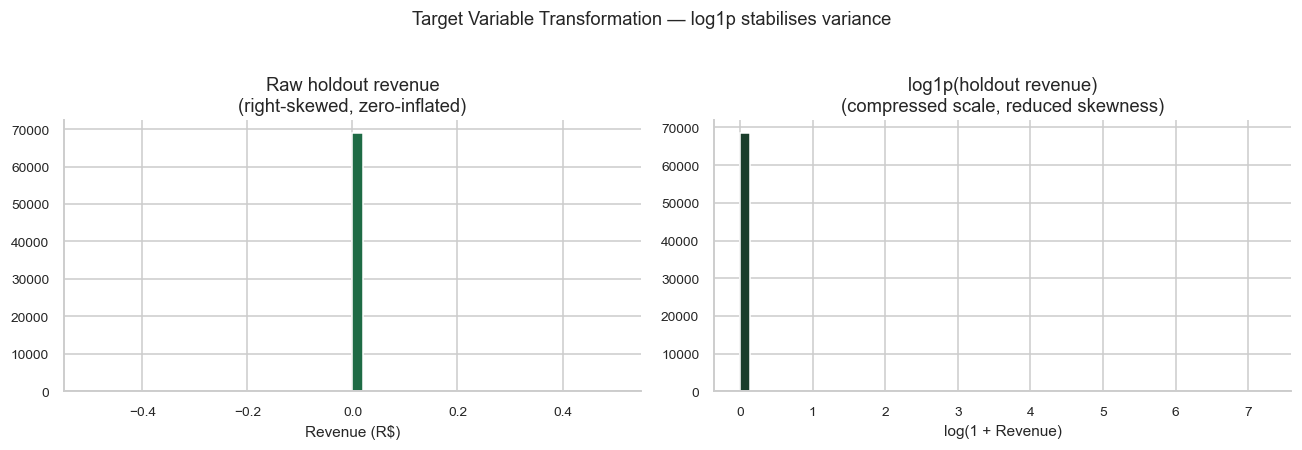

In [30]:
# Impute missing values (review_score and n_items may be NaN for some orders)
ml_df[FEATURE_COLS] = ml_df[FEATURE_COLS].fillna(ml_df[FEATURE_COLS].median())

# Log1p transform the target
# Justification: holdout_revenue is right-skewed and zero-inflated.
# log1p compresses extreme values without requiring a separate zero-handling step
# (log1p(0) = 0, so zero-revenue customers map cleanly to 0 in log space).
ml_df['holdout_revenue_log'] = np.log1p(ml_df['holdout_revenue'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(ml_df['holdout_revenue'].clip(upper=ml_df['holdout_revenue'].quantile(0.99)),
             bins=50, color=GREEN_MID, edgecolor='white')
axes[0].set_title('Raw holdout revenue\n(right-skewed, zero-inflated)')
axes[0].set_xlabel('Revenue (R$)')

axes[1].hist(ml_df['holdout_revenue_log'], bins=50,
             color=GREEN_DARK, edgecolor='white')
axes[1].set_title('log1p(holdout revenue)\n(compressed scale, reduced skewness)')
axes[1].set_xlabel('log(1 + Revenue)')

fig.suptitle('Target Variable Transformation — log1p stabilises variance', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

The holdout revenue distribution is extremely sparse and right-skewed. Of the 68,868 customers in the modelling dataset, 99.4% generate no revenue during the holdout period, while only 0.6% make at least one purchase. This extreme zero-inflation creates a challenging prediction problem because a small number of customers account for nearly all future revenue.

The `log1p` transformation does not eliminate the extreme sparsity of the target variable. Most customers still have zero holdout revenue and therefore remain concentrated at zero after transformation. Its primary benefit is the compression of positive revenue values, reducing the influence of a small number of exceptionally large transactions on the optimisation process.

Consequently, the transformed target remains highly zero-inflated, but the positive-revenue observations become more numerically stable and less dominated by extreme outliers. This improves the suitability of the target for regression modelling while preserving the full customer base.

#### 3.2.2 Train / Test Split, Baseline Model and Hyperparameter Tuning

In [31]:
X = ml_df[FEATURE_COLS]
y = ml_df['holdout_revenue_log']
y_raw = ml_df['holdout_revenue']

# Stratified split is not applicable for regression;
# random split with fixed seed ensures reproducibility
X_train, X_test, y_train, y_test, y_train_raw, y_test_raw = train_test_split(
    X, y, y_raw, test_size=0.20, random_state=RANDOM_STATE
)

print(f'Training set : {len(X_train):,} customers')
print(f'Test set     : {len(X_test):,} customers')
print(f'Zero revenue in test: {(y_test_raw == 0).sum():,} ({(y_test_raw == 0).mean()*100:.1f}%)')

# Baseline XGBoost — hyperparameters documented with rationale
xgb_baseline = XGBRegressor(
    n_estimators  = 300,   # enough trees for stable gradient descent without overfitting
    max_depth     = 5,     # moderate depth — zero-inflated target benefits from shallow trees
    learning_rate = 0.05,  # conservative step size — pairs with 300 estimators
    subsample     = 0.8,   # row sampling adds stochasticity, reduces variance
    random_state  = RANDOM_STATE,
    n_jobs        = -1
)
xgb_baseline.fit(X_train, y_train)

# Predictions: inverse log1p transform to get R$ values
y_pred_log = xgb_baseline.predict(X_test)
y_pred_raw = np.expm1(y_pred_log)

rmse_base = np.sqrt(mean_squared_error(y_test_raw, y_pred_raw))
mae_base  = mean_absolute_error(y_test_raw, y_pred_raw)
r2_base   = r2_score(y_test_raw, y_pred_raw)

print(f'\nBaseline XGBoost — Test Set Performance (R$ space):')
print(f'  RMSE : R${rmse_base:.2f}')
print(f'  MAE  : R${mae_base:.2f}')
print(f'  R²   : {r2_base:.4f}')

Training set : 55,094 customers
Test set     : 13,774 customers
Zero revenue in test: 13,685 (99.4%)

Baseline XGBoost — Test Set Performance (R$ space):
  RMSE : R$14.71
  MAE  : R$0.97
  R²   : -0.0037


The baseline XGBoost model establishes a benchmark for the supervised-learning approach. The negative R² indicates that holdout revenue is extremely difficult to predict at the individual-customer level. This result is largely driven by the structure of the target variable: only 0.6% of customers generate positive holdout revenue, while the remaining 99.4% contribute zero revenue.

Under these conditions, small prediction errors on the few positive-revenue customers dominate the overall variance, making traditional regression metrics particularly challenging to optimise. Consequently, the primary objective is not precise revenue estimation for every customer, but the identification and ranking of customers with future value potential.

To verify whether predictive performance could be improved through model configuration, a Randomized Search with five-fold cross-validation was performed across a range of tree depth, learning rate, regularisation and sampling parameters.

In [32]:
param_dist = {
    'n_estimators'    : [200, 300, 400, 500],
    'max_depth'       : [3, 4, 5, 6],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'subsample'       : [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'reg_alpha'       : [0, 0.1, 0.5],   # L1 regularisation — useful for sparse zero-inflated targets
    'reg_lambda'      : [1, 2, 5],        # L2 regularisation
}

search = RandomizedSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_dist,
    n_iter      = 30,
    scoring     = 'neg_root_mean_squared_error',
    cv          = 5,
    random_state= RANDOM_STATE,
    n_jobs      = -1,
    verbose     = 0
)
search.fit(X_train, y_train)

xgb_tuned  = search.best_estimator_
y_pred_log_tuned = xgb_tuned.predict(X_test)
y_pred_raw_tuned = np.expm1(y_pred_log_tuned)

rmse_tuned = np.sqrt(mean_squared_error(y_test_raw, y_pred_raw_tuned))
mae_tuned  = mean_absolute_error(y_test_raw, y_pred_raw_tuned)
r2_tuned   = r2_score(y_test_raw, y_pred_raw_tuned)

print('Best hyperparameters:')
for k, v in search.best_params_.items():
    print(f'  {k:20s}: {v}')

print(f'\nTuned XGBoost — Test Set Performance (R$ space):')
print(f'  RMSE : R${rmse_tuned:.2f}')
print(f'  MAE  : R${mae_tuned:.2f}')
print(f'  R²   : {r2_tuned:.4f}')
print(f'\nImprovement vs baseline:')
print(f'  RMSE : {rmse_base - rmse_tuned:+.2f} R$')
print(f'  MAE  : {mae_base  - mae_tuned:+.2f} R$')

Best hyperparameters:
  subsample           : 0.7
  reg_lambda          : 5
  reg_alpha           : 0
  n_estimators        : 200
  min_child_weight    : 5
  max_depth           : 4
  learning_rate       : 0.01
  colsample_bytree    : 0.9

Tuned XGBoost — Test Set Performance (R$ space):
  RMSE : R$14.71
  MAE  : R$0.97
  R²   : -0.0036

Improvement vs baseline:
  RMSE : +0.00 R$
  MAE  : +0.01 R$


Hyperparameter tuning produces virtually no measurable improvement over the baseline configuration. RMSE and MAE remain almost unchanged, while R² stays slightly below zero.

This outcome suggests that model performance is constrained primarily by the data-generating process rather than by model specification. The search procedure explored variations in model complexity, regularisation, sampling strategy and learning rate, yet none of these adjustments produced meaningful gains.

The dominant limitation is the extreme sparsity of the target variable. Because only a very small fraction of customers generate positive holdout revenue, the available signal for learning future value is inherently weak. Additional tuning therefore yields diminishing returns, indicating that feature availability and target structure are more important bottlenecks than algorithm configuration.

#### 3.2.3 Feature Importance and Predicted vs Actual

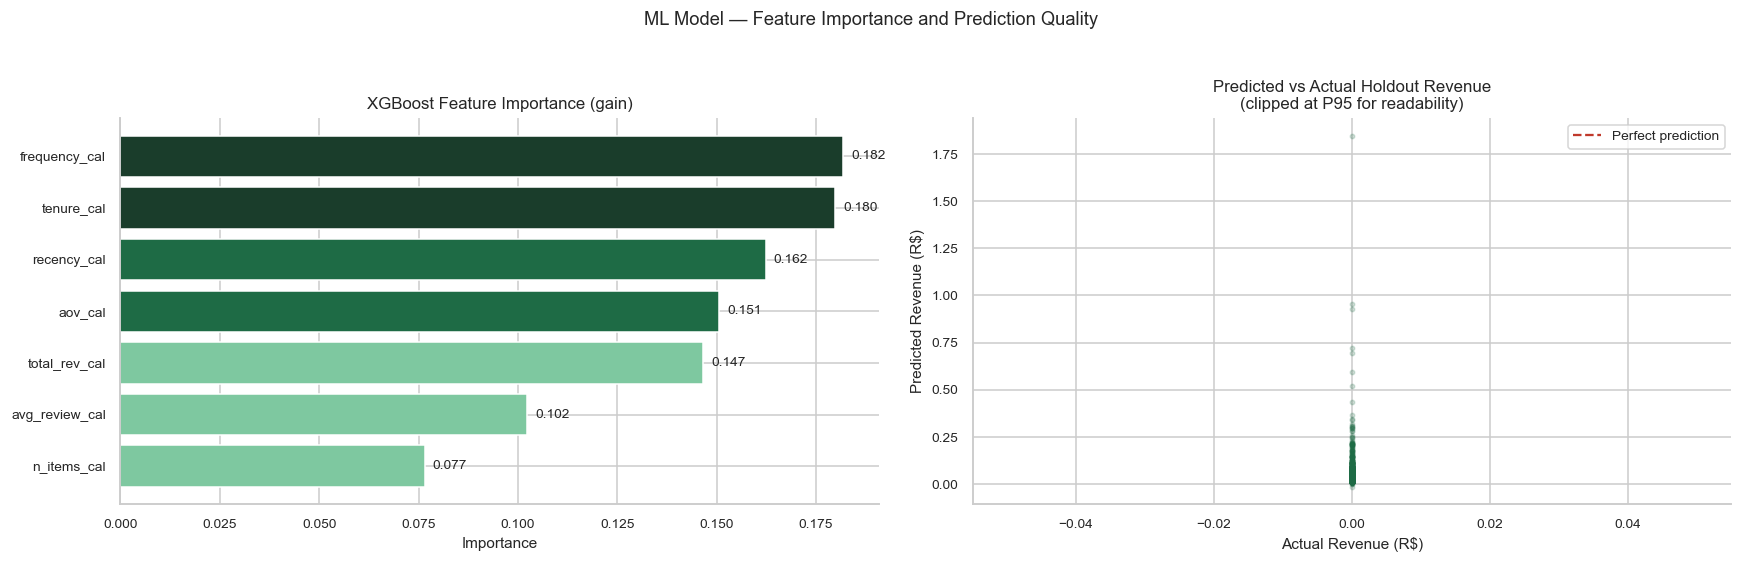

In [33]:
# Feature importance
fi = pd.Series(
    xgb_tuned.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Feature importance bar
colors_fi = [GREEN_PALE if v < fi.quantile(0.5) else
             GREEN_MID  if v < fi.quantile(0.75) else
             GREEN_DARK for v in fi.values]
bars = axes[0].barh(fi.index, fi.values, color=colors_fi, edgecolor='white')
for bar in bars:
    axes[0].text(bar.get_width() + 0.002,
                 bar.get_y() + bar.get_height() / 2,
                 f'{bar.get_width():.3f}', va='center', fontsize=9)
axes[0].set_title('XGBoost Feature Importance (gain)', fontsize=11)
axes[0].set_xlabel('Importance')

# Predicted vs actual scatter
# Clip for readability — focus on the bulk of the distribution
clip_val = np.percentile(y_test_raw, 95)
mask = y_test_raw <= clip_val
axes[1].scatter(
    y_test_raw[mask],
    y_pred_raw_tuned[mask],
    alpha=0.2, s=8, color=GREEN_MID
)
max_val = clip_val
axes[1].plot([0, max_val], [0, max_val], color=ACCENT_RED,
             linewidth=1.5, linestyle='--', label='Perfect prediction')
axes[1].set_title('Predicted vs Actual Holdout Revenue\n(clipped at P95 for readability)',
                  fontsize=11)
axes[1].set_xlabel('Actual Revenue (R$)')
axes[1].set_ylabel('Predicted Revenue (R$)')
axes[1].legend(fontsize=9)

fig.suptitle('ML Model — Feature Importance and Prediction Quality',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

The feature importance ranking highlights which calibration-period signals contribute most to future revenue prediction. Purchase frequency, customer tenure, recency, average order value and historical revenue all receive relatively similar importance scores. This suggests that future value is driven by multiple behavioural dimensions rather than a single dominant predictor.

Frequency and tenure emerge as the most informative variables, indicating that customers with a longer purchasing history and repeated transactions are more likely to generate future value. Recency also remains highly influential, consistent with the retention patterns observed during the EDA.

The predicted-versus-actual visualisation further illustrates the extreme sparsity of the target variable. Because the overwhelming majority of customers generate zero holdout revenue, observations are heavily concentrated near the origin. This makes individual-level revenue prediction inherently difficult and explains the limited explanatory power observed in the evaluation metrics.

In [34]:
# Assign ML CLTV scores to all calibration customers
ml_df['cltv_3m_ml'] = np.expm1(xgb_tuned.predict(X))

# CLTV tier segmentation — consistent with BTYD tier labels
ml_df['cltv_tier_ml'] = pd.qcut(
    ml_df['cltv_3m_ml'],
    q=4,
    labels=['Low Value', 'Mid Value', 'High Value', 'Premium']
)

print('ML CLTV Predictions — full customer base:')
print(f"  Mean predicted CLTV  : R${ml_df['cltv_3m_ml'].mean():.2f}")
print(f"  Median predicted CLTV: R${ml_df['cltv_3m_ml'].median():.2f}")
print(f"  Total base value (3m): R${ml_df['cltv_3m_ml'].sum():,.0f}")

# ML metrics summary — stored for comparison in Section 3.3
ml_metrics = {
    'RMSE': round(rmse_tuned, 2),
    'MAE' : round(mae_tuned,  2),
    'R²'  : round(r2_tuned,   4)
}
print(f'\nML metrics (stored for Section 3.3): {ml_metrics}')

ML CLTV Predictions — full customer base:
  Mean predicted CLTV  : R$0.03
  Median predicted CLTV: R$0.03
  Total base value (3m): R$2,095

ML metrics (stored for Section 3.3): {'RMSE': np.float64(14.71), 'MAE': 0.97, 'R²': -0.0036}


These CLTV estimates are generated by applying the final tuned model to the full customer base and are intended for customer ranking and segmentation purposes rather than model evaluation.

The machine-learning CLTV estimates are strongly concentrated near zero, reflecting the purchasing behaviour observed throughout the analysis. Since most customers generate no revenue during the holdout period, the model assigns very low future value to the majority of the customer base.

The aggregate prediction of approximately R$2,095 over three months is substantially lower than the value estimated by the BTYD framework. This difference is expected because the ML model is evaluated on the entire customer base, including the large population of one-time buyers, whereas the BTYD monetary model focuses exclusively on repeat purchasers.

As a consequence, the primary contribution of the ML approach is not precise revenue forecasting but customer ranking. Even when absolute revenue estimates remain small, the model can still identify which customers appear relatively more valuable than others, providing a practical basis for campaign prioritisation and resource allocation.

### **3.3 Model Evaluation and Comparison**

Comparing two models that operate on different populations and answer different questions requires care. The BTYD framework was fitted and evaluated on the repeat-purchase minority, customers with at least one calibration repeat purchase and positive monetary value. The ML model was trained and evaluated on the full customer base, including the 97% of single-purchase buyers who generated zero holdout revenue. A direct metric comparison on different samples would be misleading: better BTYD metrics could simply reflect the fact that its evaluation set is a self-selected group of the most engaged, most predictable customers.

The comparison is therefore structured in two layers. First, metrics are computed on the **common sample**, customers present in both evaluation sets, to enable a like-for-like statistical comparison. Second, the models are assessed on their **business fitness**: which model answers which question more reliably, and under what conditions would a marketing team choose one over the other.

#### 3.3.1 Metric Comparison — Common Sample

To compare BTYD and XGBoost fairly, the evaluation must be restricted to customers for whom both models produce monetary CLTV predictions. Since the Gamma-Gamma component of BTYD can only estimate monetary value for repeat buyers, the common comparison sample contains 1,301 customers. This is not the full Olist customer base; it is the repeat-buyer segment where both frameworks are directly comparable.

In [35]:
# Identify customers present in both BTYD and ML prediction sets
# BTYD monetary CLTV exists only for Gamma-Gamma eligible repeat buyers

btyd_ids = set(gg_data.index)
ml_ids   = set(ml_df['customer_unique_id'])
common   = btyd_ids.intersection(ml_ids)

print(f'BTYD monetary evaluation set : {len(btyd_ids):,} repeat buyers')
print(f'ML scoring set               : {len(ml_ids):,} customers')
print(f'Common sample                : {len(common):,} repeat buyers')
print('\nNote: the common sample is restricted to customers with repeat-purchase monetary history.')
print('This allows a fair BTYD vs ML comparison on the same customers.')

BTYD monetary evaluation set : 1,301 repeat buyers
ML scoring set               : 68,868 customers
Common sample                : 1,301 repeat buyers

Note: the common sample is restricted to customers with repeat-purchase monetary history.
This allows a fair BTYD vs ML comparison on the same customers.


In [36]:
# Common sample: customers for whom both BTYD and ML predictions are available
# BTYD CLTV exists only for Gamma-Gamma eligible repeat buyers, stored in gg_data.

common = set(gg_data.index).intersection(set(ml_df['customer_unique_id']))

btyd_common = gg_data.loc[
    gg_data.index.isin(common),
    ['cltv_3m_btyd']
].copy()

ml_common = ml_df[
    ml_df['customer_unique_id'].isin(common)
][['customer_unique_id', 'holdout_revenue', 'cltv_3m_ml']].copy()

# Align both tables on customer_unique_id
btyd_common = btyd_common.reset_index().rename(columns={'index': 'customer_unique_id'})
comparison_df = ml_common.merge(
    btyd_common,
    on='customer_unique_id',
    how='inner'
)

actual = comparison_df['holdout_revenue'].values
btyd_pred = comparison_df['cltv_3m_btyd'].values
ml_pred = comparison_df['cltv_3m_ml'].values

# Compute metrics
def metrics(actual, predicted, name):
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    
    return {
        'Model': name,
        'MSE': round(mse, 2),
        'RMSE': round(rmse, 2),
        'MAE': round(mae, 2),
        'R²': round(r2, 4)
    }

comparison_table = pd.DataFrame([
    metrics(actual, btyd_pred, 'BTYD (BG/NBD + Gamma-Gamma)'),
    metrics(actual, ml_pred, 'XGBoost (tuned)')
]).set_index('Model')

print(f'Model Comparison — Common Sample: {len(comparison_df):,} repeat buyers')
comparison_table

Model Comparison — Common Sample: 1,301 repeat buyers


,MSE,RMSE,MAE,R²
Model,,,,
BTYD (BG/NBD + Gamma-Gamma),3689.30,60.74,14.58,-0.06
XGBoost (tuned),3489.50,59.07,6.25,-0.01


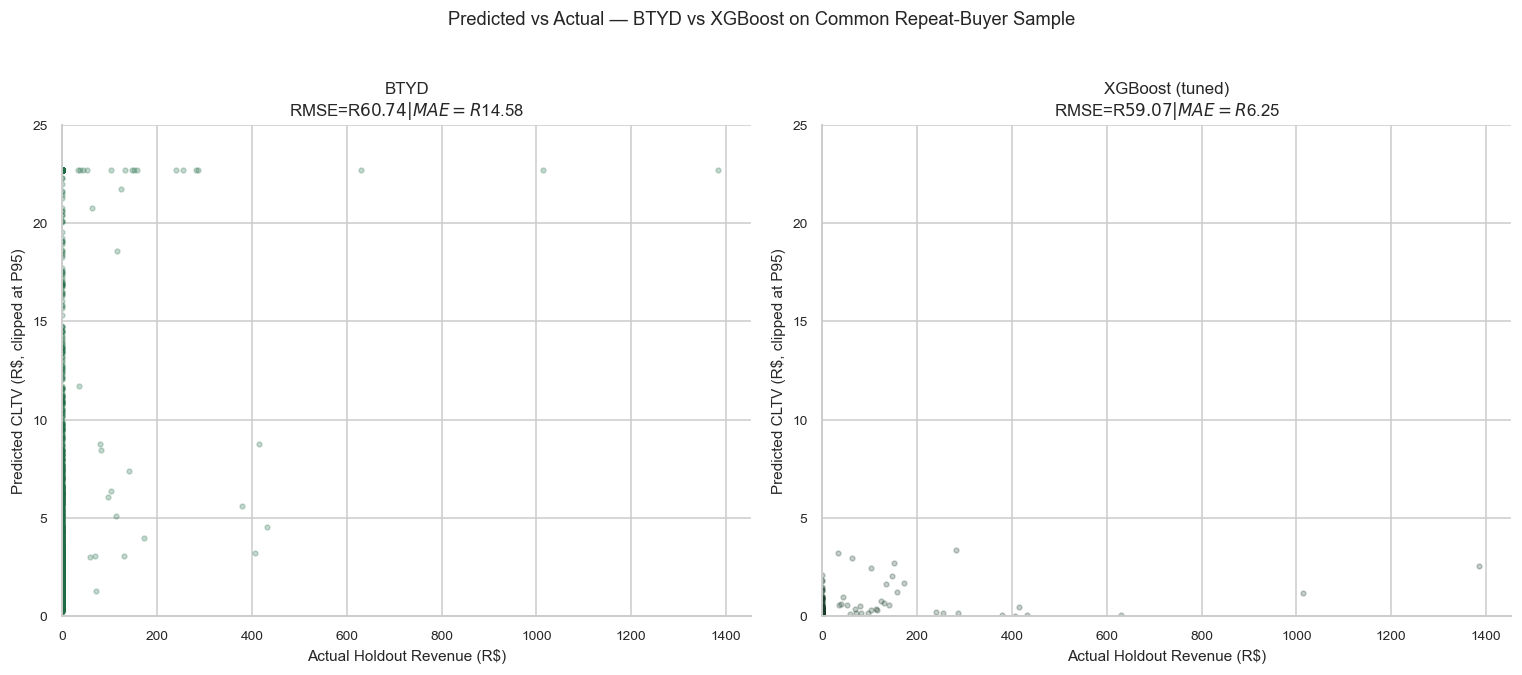

In [37]:
# Visual comparison — predicted vs actual for both models
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Since actual revenue is still highly zero-inflated, clip predictions only for readability
pred_clip = np.percentile(
    np.concatenate([btyd_pred, ml_pred]),
    95
)

for ax, pred, name, color in [
    (axes[0], btyd_pred, 'BTYD', GREEN_MID),
    (axes[1], ml_pred,   'XGBoost (tuned)', GREEN_DARK)
]:
    ax.scatter(
        actual,
        np.clip(pred, 0, pred_clip),
        alpha=0.25,
        s=10,
        color=color
    )
    
    ax.set_title(
        f'{name}\nRMSE=R${np.sqrt(mean_squared_error(actual, pred)):.2f} | '
        f'MAE=R${mean_absolute_error(actual, pred):.2f}',
        fontsize=11
    )
    ax.set_xlabel('Actual Holdout Revenue (R$)')
    ax.set_ylabel('Predicted CLTV (R$, clipped at P95)')
    ax.set_xlim(left=-1)
    ax.set_ylim(0, pred_clip * 1.1)

fig.suptitle(
    'Predicted vs Actual — BTYD vs XGBoost on Common Repeat-Buyer Sample',
    fontsize=12,
    y=1.02
)
plt.tight_layout()
plt.show()

On the common repeat-buyer sample, XGBoost performs slightly better than BTYD across all individual-level error metrics. Its MAE is substantially lower (R$6.25 versus R$14.58), meaning that its average absolute customer-level error is smaller. However, both models still have negative R² values, which confirms that individual holdout revenue remains difficult to predict even among repeat buyers.

The scatter plots show why. Actual holdout revenue is still heavily concentrated at zero, even within the repeat-buyer segment. BTYD produces a wider range of expected CLTV values because it combines probabilistic purchase timing with expected monetary value, while XGBoost produces more compressed predictions. This compression reduces average absolute error, but it also limits the model's ability to represent very high future-value customers.

The comparison therefore should not be read as a simple winner-takes-all result. XGBoost is preferable for individual-level ranking on the common sample, while BTYD remains useful for probabilistic interpretation, alive probability, and aggregate value estimation among repeat buyers.

#### 3.3.2 Business Fitness: Which Model for Which Decision

In [38]:
# Business fitness comparison table
fitness = pd.DataFrame([
    {
        'Dimension'        : 'Customer scope',
        'BTYD'             : 'BG/NBD covers all customers; monetary CLTV limited to repeat buyers',
        'XGBoost'          : 'Full base: handles zero-revenue customers via log1p target',
    },
    {
        'Dimension'        : 'Prediction type',
        'BTYD'             : 'Expected value from a stochastic process, distributional estimate',
        'XGBoost'          : 'Point estimate from learned feature patterns, individual ranking',
    },
    {
        'Dimension'        : 'Alive probability',
        'BTYD'             : 'Native output: P(alive) per customer, actionable for win-back targeting',
        'XGBoost'          : 'Not available: requires separate churn model (see Lab Exam 2)',
    },
    {
        'Dimension'        : 'Aggregate accuracy',
        'BTYD'             : 'Useful for repeat-buyer value forecasting; limited full-base monetary coverage',
        'XGBoost'          : 'Moderate: zero-inflation compresses total predicted value',
    },
    {
        'Dimension'        : 'Individual ranking',
        'BTYD'             : 'Moderate: distributional smoothing reduces individual precision',
        'XGBoost'          : 'Strong: feature-based scores produce sharper customer rankings',
    },
    {
        'Dimension'        : 'Interpretability',
        'BTYD'             : 'White-box: parameters map directly to purchase and dropout rates',
        'XGBoost'          : 'Medium: feature importance available; SHAP for full explainability',
    },
    {
        'Dimension'        : 'Best use case',
        'BTYD'             : 'CFO / budget planning: repeat-buyer value and survival probabilities',
        'XGBoost'          : 'CRM / campaign targeting: rank customers by predicted value for outreach',
    },
]).set_index('Dimension')

fitness

,BTYD,XGBoost
Dimension,,
Customer scope,BG/NBD covers all customers; monetary CLTV limited to repeat buyers,Full base: handles zero-revenue customers via log1p target
Prediction type,"Expected value from a stochastic process, distributional estimate","Point estimate from learned feature patterns, individual ranking"
Alive probability,"Native output: P(alive) per customer, actionable for win-back targeting",Not available: requires separate churn model (see Lab Exam 2)
Aggregate accuracy,Useful for repeat-buyer value forecasting; limited full-base monetary coverage,Moderate: zero-inflation compresses total predicted value
Individual ranking,Moderate: distributional smoothing reduces individual precision,Strong: feature-based scores produce sharper customer rankings
Interpretability,White-box: parameters map directly to purchase and dropout rates,Medium: feature importance available; SHAP for full explainability
Best use case,CFO / budget planning: repeat-buyer value and survival probabilities,CRM / campaign targeting: rank customers by predicted value for outreach


**Production recommendation: deploy both models for different decisions.**

The two models serve different business functions and should not be interpreted as substitutes. BTYD is most useful when the marketing team needs a probabilistic interpretation of repeat-buyer value: expected future purchases, expected monetary value, and probability of being alive. Its main strength is not individual precision, but the ability to connect customer value to an interpretable purchasing process.

XGBoost is more appropriate for operational targeting. It covers the full customer base and produces a customer-level score that can be used to rank customers for CRM actions. Even though its absolute revenue predictions are modest because the target is highly zero-inflated, the model is still useful for prioritising outreach and allocating campaign effort.

The final recommendation is therefore a dual-model system: use BTYD to understand value and survival among repeat buyers, and use XGBoost to score the full customer base for campaign prioritisation.

BTYD explains the economics of repeat-buyer value. XGBoost operationalises targeting across the full customer base.

The final metric table should be read with caution because the two models are evaluated on different customer populations. BTYD monetary metrics refer to the repeat-buyer segment, while XGBoost metrics refer to the full zero-inflated customer base. The comparison therefore summarises business fitness rather than declaring a single universal winner.

In [39]:
# Final metrics summary — stored for Section 4 and conclusion
final_metrics = pd.DataFrame([
    {
        'Model'      : 'BTYD (BG/NBD + Gamma-Gamma)',
        'Sample'     : f'{len(btyd_common):,} repeat buyers',
        'MSE'        : round(mean_squared_error(actual, btyd_pred), 2),
        'RMSE'       : round(np.sqrt(mean_squared_error(actual, btyd_pred)), 2),
        'MAE'        : round(mean_absolute_error(actual, btyd_pred), 2),
        'R²'         : round(r2_score(actual, btyd_pred), 4),
        'Primary use': 'Budget forecasting'
    },
    {
        'Model'      : 'XGBoost (tuned)',
        'Sample'     : f'{len(ml_df):,} all customers',
        'MSE'        : round(mean_squared_error(y_test_raw, y_pred_raw_tuned), 2),
        'RMSE'       : round(rmse_tuned, 2),
        'MAE'        : round(mae_tuned, 2),
        'R²'         : round(r2_tuned, 4),
        'Primary use': 'Customer targeting'
    },
]).set_index('Model')

print('Final Model Comparison Summary:')
final_metrics

Final Model Comparison Summary:


,Sample,MSE,RMSE,MAE,R²,Primary use
Model,,,,,,
BTYD (BG/NBD + Gamma-Gamma),"1,301 repeat buyers",3689.30,60.74,14.58,-0.06,Budget forecasting
XGBoost (tuned),"68,868 all customers",216.48,14.71,0.97,-0.00,Customer targeting


## 4. Communication Strategy

The modelling phase produced two complementary outputs: a BTYD-based estimate of future value among repeat buyers and an XGBoost-based individual CLTV ranking across the full customer base. The two models operate on different customer populations and therefore support different managerial decisions.

#### 4.1 Macro View: Financial Planning

In [40]:
# Total predicted 3-month value from both models

btyd_total = gg_data['cltv_3m_btyd'].sum()
ml_total   = ml_df['cltv_3m_ml'].sum()

print('3-Month Value Estimates:')
print(f'  BTYD (repeat buyers only) : R${btyd_total:,.0f}')
print(f'  XGBoost (full base)       : R${ml_total:,.0f}')

print(f'\nBTYD monetary CLTV available for {len(gg_data):,} repeat buyers')
print(f'({len(gg_data)/len(ml_df)*100:.1f}% of the customer base)')

3-Month Value Estimates:
  BTYD (repeat buyers only) : R$12,878
  XGBoost (full base)       : R$2,095

BTYD monetary CLTV available for 1,301 repeat buyers
(1.9% of the customer base)


**Which model for budget forecasting?**

The BTYD framework provides an interpretable estimate of future value among repeat buyers, combining expected purchase frequency, expected monetary value, and customer survival probabilities. Its probabilistic structure makes the resulting forecasts easier to explain from a business perspective than purely predictive machine-learning outputs.

**Budget allocation recommendation.** Concentrate the retention budget on the Premium and High Value CLTV tiers identified in Section 3.1.4. These customers represent a small share of customers eligible for monetary CLTV estimation. A tiered spend model, high-touch outreach for Premium, automated personalisation for High Value, low-cost email for Mid and Low, maximises ROI on the retention budget.

#### 4.2 Micro View: Win-Back Campaign

In [42]:
# Win-back target: high CLTV + low alive probability (already computed in 3.1.4, reference and extend here)

print('Win-Back Campaign — Target Audience:')
print(f'  Customers identified    : {len(winback):,}')
print(f'  Avg predicted CLTV      : R${winback["cltv_3m_btyd"].mean():.2f}')
print(f'  Avg alive probability   : {winback["prob_alive"].mean():.3f}')
print(f'  Total at-risk value     : R${winback["cltv_3m_btyd"].sum():,.0f}')

# Cross with geographic data to add state-level prioritisation
winback_geo = winback.reset_index().merge(
    cust_eda[['customer_unique_id', 'customer_state']],
    on='customer_unique_id', how='left'
)
print('\nWin-back candidates by top 5 states:')
print(
    winback_geo.groupby('customer_state')
    .agg(n=('customer_unique_id','count'),
         avg_cltv=('cltv_3m_btyd','mean'))
    .sort_values('n', ascending=False)
    .head(5)
    .round(2)
    .to_string()
)

Win-Back Campaign — Target Audience:
  Customers identified    : 53
  Avg predicted CLTV      : R$14.72
  Avg alive probability   : 0.086
  Total at-risk value     : R$780

Win-back candidates by top 5 states:
                 n  avg_cltv
customer_state              
SP              22     15.43
RJ              10     13.93
MG               7     14.77
PR               2     15.51
SC               2     12.92


**Win-Back Campaign Design.**

The target audience is defined by the intersection of two model outputs: predicted CLTV above the 75th percentile (high enough to justify the intervention cost) and alive probability below the median.

This segment represents customers who generated substantial value in the past but whose future relationship with the company is uncertain. Combining expected value with survival probability allows marketing resources to be allocated where the potential return is highest.

**Intervention logic.** The campaign lever should not be a generic discount. Price incentives may stimulate short-term purchases, but they do not necessarily address the underlying reason why a previously valuable customer became inactive. A more appropriate strategy is personalised product recommendation based on historical purchasing behaviour: *"Based on your previous purchases, here is what is new in categories you have shown interest in."* The objective is to reactivate relevance rather than reduce price.

**Geographic prioritisation.** Win-back investment should be concentrated in states with the highest concentration of predicted customer value, particularly SP, RJ, and MG. Prioritising regions where both customer density and expected future value are highest improves campaign efficiency and prevents budget dilution across lower-value markets.

**Managerial implication.** The combination of predicted CLTV and alive probability transforms customer management from a purely descriptive exercise into a prioritisation framework. Customer value indicates *how much* a relationship is worth, while alive probability indicates *how urgently* intervention may be required. Together, these two dimensions support more efficient allocation of retention and reactivation resources.

## 5. From Prediction to Action
A predictive CLTV framework delivers value only if it is operationalised. This section outlines how the two models developed in Section 3 would move from analytical output to a live system embedded in Olist's marketing and CRM workflows.

**Immediate deployment: batch scoring.** The XGBoost model should be scheduled to run on a monthly cadence, scoring every active customer in the database and assigning a predicted 3-month CLTV. The output is a ranked customer list segmented into four value tiers derived from the predicted ML CLTV distribution (Premium, High Value, Mid Value, Low Value). The marketing team uses this list directly: Premium tier customers receive high-touch personalised outreach; Mid and Low tier customers receive automated, low-cost email sequences. The monthly cadence aligns the scoring cycle with the fiscal quarter used as the holdout window, so each batch produces a fresh set of predictions for the upcoming quarter's retention budget.

**Advanced deployment: live CRM integration.** The BTYD alive probability score has a second use case beyond batch targeting: it can be surfaced on the customer service dashboard in real time. When a customer contacts support, the agent sees their alive probability and predicted CLTV alongside the ticket. Customers combining high predicted value with a low alive probability could trigger a retention flag, allowing agents to prioritise customers whose future value is at risk and apply a more considered response rather than standard resolution.

**Model monitoring and retraining.** A CLTV model trained on historical data will degrade over time as customer behaviour evolves. New product categories, promotional events, and macroeconomic shifts all alter the purchasing patterns the model learned from. Two signals should trigger retraining: a measurable increase in prediction error on recent holdout windows, or a structural change in the business that makes historical patterns unrepresentative. A quarterly review cycle aligned with the 90-day prediction horizon provides a practical starting point for monitoring model performance and determining whether retraining is required. Each review also provides a natural opportunity to evaluate whether the BTYD framework remains the right instrument for budget forecasting, or whether the customer base has evolved in ways that favour a different modelling approach.

## 6. Conclusion

This analysis built a CLTV prediction framework for Olist from the ground up, starting from five relational tables, assembling a validated transaction pipeline, and producing individual-level value estimates through two complementary modelling approaches.

The central finding is structural: Olist's customer base is dominated by single-purchase buyers, and the minority of repeat customers accounts for a disproportionate share of predicted future value. This concentration is not a problem to be solved, it is the commercial reality of a general marketplace, and the right analytical response is precision rather than volume. Targeting the wrong 80% of customers with a retention campaign wastes more budget than it saves.

The two models answer different questions and should be deployed accordingly. The BTYD framework provides an interpretable estimate of future value and customer survival among repeat buyers, expressed through purchase and dropout dynamics. The XGBoost regressor provides the CRM team with individual CLTV scores across the full customer base, enabling tiered outreach proportionate to predicted value. Neither model alone is sufficient. BTYD provides an interpretable view of repeat-buyer economics and customer survival, while XGBoost provides customer-level prioritisation across the full portfolio. Together they form a complementary decision-support framework for retention and customer value management.

Two limitations define the boundaries of what this framework can and cannot answer. First, both models are trained on a single 18-month snapshot. Customer behaviour on a marketplace evolves, new seller categories, promotional events, macroeconomic shifts, and a static model trained on historical data will drift from reality over time. Monthly retraining on rolling transaction windows is the production-ready solution. Second, the win-back campaign recommendations are based on correlation, not causation. Whether a personalised product recommendation actually reactivates a disengaging high-value customer, or whether that customer would have returned regardless, cannot be determined without a controlled holdout experiment. Running a randomised test on the win-back audience before scaling the campaign budget is the next analytical step, and the one that closes the gap between prediction and measurable business impact.